#1.0 Install dependencies

In [ ]:
!pip install pyarrow --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

sns.set(style="whitegrid")


#1.1 Create & save DataFrame as Feather

In [ ]:
import pyarrow.feather as feather
import os

customers = pd.read_csv("customers.csv")
accounts = pd.read_csv("accounts.csv")
linkage = pd.read_csv("customer_account_linkage.csv")
products = pd.read_csv("product_details.csv")
labels = pd.read_csv("train_labels.csv")
test = pd.read_csv("test_accounts.csv")

# Transactions are split across 6 files due to GitHub size limits — concatenate them
transactions = pd.concat(
    [pd.read_csv(f"transactions_part_{i}.csv", on_bad_lines='skip')
     for i in range(6)],
    ignore_index=True
)


In [ ]:
for name, df in [("customers", customers), ("accounts", accounts),
                 ("linkage", linkage), ("products", products),
                 ("labels", labels), ("transactions", transactions)]:
    print(f"\n{'='*40}")
    print(f"{name}: {df.shape}")
    print(df.dtypes)
    print(f"\nMissing values:\n{df.isnull().sum()}")


customers: (39988, 14)
customer_id                object
date_of_birth              object
relationship_start_date    object
pan_available              object
aadhaar_available          object
passport_available         object
mobile_banking_flag        object
internet_banking_flag      object
atm_card_flag              object
demat_flag                 object
credit_card_flag           object
fastag_flag                object
customer_pin                int64
permanent_pin               int64
dtype: object

Missing values:
customer_id                   0
date_of_birth                 0
relationship_start_date       0
pan_available              5732
aadhaar_available          9708
passport_available            0
mobile_banking_flag           0
internet_banking_flag         0
atm_card_flag                 0
demat_flag                    0
credit_card_flag              0
fastag_flag                   0
customer_pin                  0
permanent_pin                 0
dtype: int64

account

In [ ]:
print("Customers:", customers.shape)
print("Accounts:", accounts.shape)
print("Transactions:", transactions.shape)
print("Labels:", labels.shape)


Customers: (39988, 14)
Accounts: (40038, 22)
Transactions: (1552699, 8)
Labels: (24023, 5)


In [ ]:
labels['is_mule'].value_counts()

,count
is_mule,
0,23760
1,263


In [ ]:
labels['is_mule'].value_counts(normalize=True)

,proportion
is_mule,
0,0.989052
1,0.010948


In [ ]:
print(f"Mule rate: {labels['is_mule'].mean():.4f}")

Mule rate: 0.0109


<font size = 8> Master table

In [ ]:
train = labels.merge(accounts, on="account_id", how="left")

In [ ]:
train = train.merge(linkage, on="account_id", how="left")
train = train.merge(customers, on="customer_id", how="left")
train = train.merge(products, on="customer_id", how="left")

# 1.3 Save locally first (Colab's temp storage)

In [ ]:
local_path = "/content/train_data.feather"

feather.write_feather(train, local_path)

print(f"Feather file saved locally: {local_path}")
print(f"File size: {os.path.getsize(local_path):,} bytes")

Feather file saved locally: /content/train_data.feather
File size: 4,502,874 bytes


#1.4 Mount Google Drive & copy temp file to G-Drive

In [ ]:

from google.colab import drive

drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#1.5 Choosing target folder inside Drive
`os.mkdirs` method creates a subfolder called feather_data

In [ ]:
drive_folder = "/content/drive/My Drive/IITD_Hack/Submissions"

os.makedirs(drive_folder, exist_ok=True) # makes a sub-directory called feather_data

drive_path = os.path.join(drive_folder, "my_data.feather")

# Copy local feather file → Google Drive
import shutil
shutil.copy(local_path, drive_path)

print(f" Feather file saved to Google Drive: {drive_path}")

 Feather file saved to Google Drive: /content/drive/My Drive/IITD_Hack/Submissions/my_data.feather


#1.6 Read feather file back from Google Drive

In [ ]:
df_loaded = feather.read_feather(drive_path)

print(f" Feather file loaded from Google Drive")
print(f" Shape: {df_loaded.shape}")
print(df_loaded.head())


 Feather file loaded from Google Drive
 Shape: (24023, 50)
    account_id  is_mule mule_flag_date alert_reason  flagged_by_branch  \
0  ACCT_023272        0           None         None                NaN   
1  ACCT_062177        0           None         None                NaN   
2  ACCT_194388        0           None         None                NaN   
3  ACCT_064626        0           None         None                NaN   
4  ACCT_063119        0           None         None                NaN   

  account_status  product_code  currency_code account_opening_date  \
0         active          1102              1           2023-08-03   
1         active           804              1           2023-08-17   
2         active          1133              1           2023-11-23   
3         active           187              1           2017-06-25   
4         active           200              1           2023-04-05   

   branch_code  ...   loan_sum  loan_count    cc_sum cc_count    od_sum  \


In [ ]:
are_equal = df.equals(df_loaded)
print(f" Original and loaded DataFrames match: {are_equal}")

 Original and loaded DataFrames match: False


#1.7 Summary of the DataFrame

In [ ]:
!pip install summarytools
from summarytools import dfSummary


df_summary = dfSummary(train)
df_summary

No,Variable,Stats / Values,Freqs / (% of Valid),Graph,Missing
1,account_id[object],1. ACCT_0225332. ACCT_0232723. ACCT_0621774. ACCT_1943885. ACCT_0646266. ACCT_0631197. ACCT_0028408. ACCT_1348399. ACCT_19156110. ACCT_00932911. other,"1 (0.0%)1 (0.0%)1 (0.0%)1 (0.0%)1 (0.0%)1 (0.0%)1 (0.0%)1 (0.0%)1 (0.0%)1 (0.0%)24,013 (100.0%)","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAJsAAAD+CAYAAAAtWHdlAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAy5JREFUeJzt3MGN02AURtHnKIJhY2tkKSVADymCLb3ThTcwrMKCHq4lc04F/+JKT5H8ZXm9XgOF29kP4P8hNjJiIyM2MmIjIzYyYiMjNjJiIyM2MrdlWb4ty/J29kO4vtvMfJ2Zz2c/hOtzRsmIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNzG1mfs7Mn7MfwvUt/sWIijNKRmxkrKvIWFeRcUbJiI2M2MiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MgYvJAxeCHjjJIRGxmDFzIGL2ScUTJiIyM2MmIjIzYyYiMjNjJiIyM2MmIjIzYyYiMjNjJiIyM2MgYvZAxeyDijZMRGRmxkrKvIWFeRcUbJiI2M2MiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MhYV5GxriLjjJIRGxmDFzIGL2ScUTJiIyM2MmIjIzYyYiMjNjJiIyM2MmIjIzYyYiMjNjJiIyM2MgYvZAxeyDijZMRGxuCFjMELGWeUjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MhYV5GxriLjjJIRGxnrKjLWVWScUTJiIyM2MmIjIzYyYiMjNjJiIyM2MmIjIzYyYiMjNjJiIyM2MgYvZAxeyDijZMRGxuCFjMELGWeUjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNjIiI2MwQsZgxcyzigZsZERGxnrKjLWVWScUTJiIyM2MmIjIzYyYiMjNjJiIyM2MmIjIzYyYiMjNjJiIyM2MtZVZKyryDijZMRGxuCFjMELGWeUjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNjIiI2MwQsZgxcyziiZZWa+zMynsx/C9d33ff++ruv72Q/h+u7rur4/n8/f27Z9nP0Yrus4jrf7zMy2bR+Px+PX2Q/i2vxAICM2MmIjIzYyYiMjNjJiIyM2MmIjIzYyYiMjNjJiI3Of+ff5x9kP4dqO43hb9n3/4eNJCj4LJ2NdRcYPBDJiIyM2MmIjIzYyYiMjNjJiIyM2Mn8BY+dLgsx6ZCoAAAAASUVORK5CYII="">",0(0.0%)
2,is_mule[int64],1. 02. 1,"23,760 (98.9%)263 (1.1%)","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAJsAAAAuCAYAAAA/ZmtKAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAURJREFUeJzt28Ftg0AYROEBISdcFiFLLsMFuIgUmyIogD4QYg9Zh8vmENtyAfGstHlfBXN4QgjxNzlnAQ6NpF7SofQQVG3POafueDx+hBDG0mtQrxjj2jTNZxdCGC+XSxqG4Vp6FOqzbdv7NE3jsiyHTpKGYbieTqev0sNQrV6S2tIr8H8QG2yIDTbEBhtigw2xwYbYYENssCE22BAbbIgNNsQGG2KDDbHBhthg00m/P7iVHoI6PbfVxRjXaZpG3X5wA/5ajHGVtHPwAoc955waTvng8vxk23POqfAeVOxxync/tyI4vEobQhjP57Nut6O8u+FlWknq+/679BDUj4+6sCE22BAbbIgNNsQGG2KDDbHBhthgQ2ywITbYEBtsiA02xAYbYoMNscGmlaSU0lvpIahfG2Nc53l+nFuVHoR6cfACmx8aqlbZirmwDAAAAABJRU5ErkJggg=="">",0(0.0%)
3,mule_flag_date[object],1. nan2. 2025-06-293. 2024-06-304. 2025-07-015. 2022-03-316. 2025-04-157. 2025-07-028. 2025-07-039. 2025-06-2110. 2025-07-0511. other,"23,760 (98.9%)9 (0.0%)8 (0.0%)8 (0.0%)8 (0.0%)8 (0.0%)7 (0.0%)5 (0.0%)4 (0.0%)4 (0.0%)202 (0.8%)","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAJsAAAD+CAYAAAAtWHdlAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAA4lJREFUeJzt3LFtI2cURtE3AiFbyRAEAZVg96AittgtgkVsD4KgCVZrJePAG7gA7x2APidS+AcXeCTAT8u+7wOFh6MfwP+H2MiIjYzYyIiNjNjIiI2M2MiIjcwyM08z83j0Q7hrn/u+f5yu1+uXdV0vR7+G+7Vt29uyLF9P67peXl5ePs7n84+jH8X9eX9///12u11eX18fTzMz5/P5x/Pz8/ejH8bdeprxBYGQ2MiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MicZv75zdHRD+E+/but07Ztb7fb7TI/f3ME/7Vt295m5tMGgcLnvu8fi3+ZRcUXBDIPy7L8uSyLLwj8cg8z88fM/Hb0Q7h/zigZsZERGxmxkREbGbGRERsZsZERGxmxkREbGbGRERsZsZERG5mHmfk2M38d/RDunw0CGWeUjNjIGLyQMXgh44ySERsZsZERGxmxkREbGbGRERsZsZERGxmxkREbGbGRERsZsZExeCFj8ELGGSUjNjJiI2NdRca6iowzSkZsZMRGRmxkxEZGbGTERkZsZMRGRmxkxEZGbGTERkZsZMRGxrqKjHUVGWeUjNjIGLyQMXgh44ySERsZsZERGxmxkREbGbGRERsZsZERGxmxkREbGbGRERsZsZExeCFj8ELGGSUjNjIGL2QMXsg4o2TERkZsZMRGRmxkxEZGbGTERkZsZMRGRmxkxEZGbGTERkZsZMRGxrqKjHUVGWeUjNjIWFeRsa4i44ySERsZsZERGxmxkREbGbGRERsZsZERGxmxkREbGbGRERsZsZExeCFj8ELGGSUjNjIGL2QMXsg4o2TERkZsZMRGRmxkxEZGbGTERkZsZMRGRmxkxEZGbGTERkZsZAxeyBi8kHFGyYiNjNjIWFeRsa4i44ySERsZsZERGxmxkREbGbGRERsZsZERGxmxkREbGbGRERsZsZGxriJjXUXGGSUjNjIGL2QMXsg4o2TERkZsZMRGRmxkxEZGbGTERkZsZMRGRmxkxEZGbGTERkZsZAxeyBi8kHFGySwz8zQzs+/7x8Fv4c6drtfrl5mZZVm+Co5f6WFd18u6rpeZeTz6Mdw3n9nIiI2M2MiIjYzYyIiNjNjIiI2M2MiIjYzY

#2. Now we will segregate the continuous and categorical variables

In [ ]:
cat_cols = train.select_dtypes(include=['object']).columns.tolist()

num_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical:", cat_cols)
print("Numerical:", num_cols)


Categorical: ['account_id', 'mule_flag_date', 'alert_reason', 'account_status', 'account_opening_date', 'product_family', 'nomination_flag', 'cheque_allowed', 'cheque_availed', 'last_mobile_update_date', 'kyc_compliant', 'last_kyc_date', 'rural_branch', 'freeze_date', 'unfreeze_date', 'customer_id', 'date_of_birth', 'relationship_start_date', 'pan_available', 'aadhaar_available', 'passport_available', 'mobile_banking_flag', 'internet_banking_flag', 'atm_card_flag', 'demat_flag', 'credit_card_flag', 'fastag_flag']
Numerical: ['is_mule', 'flagged_by_branch', 'product_code', 'currency_code', 'branch_code', 'branch_pin', 'avg_balance', 'num_chequebooks', 'monthly_avg_balance', 'quarterly_avg_balance', 'daily_avg_balance', 'customer_pin', 'permanent_pin', 'loan_sum', 'loan_count', 'cc_sum', 'cc_count', 'od_sum', 'od_count', 'ka_sum', 'ka_count', 'sa_sum', 'sa_count']


Certain variables were excluded from categorical and continuous feature analysis because they do not represent meaningful behavioral, financial, or transactional characteristics that can explain mule account behavior. Including such variables would either provide no predictive value or introduce bias and data leakage.

These excluded variables fall into the following categories:

**1.Identifier Variables (Unique Entity Identifiers) :**
- account_id
- customer_id


These variables are unique identifiers assigned to each account or customer for database indexing and record management purposes.They do not represent any behavioral, financial, or transactional attribute and therefore were excluded from feature analysis and modeling. <br>
<br>

**2.Temporal Variables (Raw Date Fields):**
- account_opening_date
- last_mobile_update_date
- last_kyc_date
- freeze_date
- unfreeze_date
- date_of_birth
- relationship_start_date
- mule_flag_date

Temporal variables represent timestamps rather than behavioral attributes. These variables were excluded in their raw form and instead used to derive meaningful features such as account age, customer age, and recency metrics, which are more relevant for detecting mule behavior.
<br>
<br>


 **3. Data Leakage Variable (Post-Event Information):**
- alert_reason
- flagged_by_branch

these represents post-detection information that is only available after an account has been identified as fraudulent. Including this variable would introduce data leakage and lead to unrealistic model performance. Therefore, it was excluded from analysis.
<br>
<br>

**4. Encoded Categorical Identifiers (Numerical Codes Without Quantitative Meaning) :**

- product_code (redundant with product_family)
- currency_code (no unique values all 1 - refer to summary(1.7))
- branch_code
- branch_pin
- customer_pin
- permanent_pin

Variables such as branch_code, product_code, and PIN codes represent categorical identifiers or geographic labels rather than measurable continuous quantities. These variables lack meaningful numerical magnitude or ordering and were therefore excluded from raw continuous feature analysis but used to derive features like branch mule concentration, PIN mismatch flag, and geographic consistency score.

In respect of suspected mule accounts, customer_pin and permanent_pin are useful for the bank to alert local police and cid to start physical surveillance of fraudsters offices/ locations. With sufficient evidence gathered from electronic surveillance the police dept will raid fraudsters' premises

Also, IFSC code can be extracted by branch_code but customer_id already contains branch_code therefore to reduce redundancy we eliminate the variable

#2.1 After excluding irrelevant and non-informative variables, the final list of Categorical and Numerical Columns was obtained

In [ ]:
cat_cols = [
    'account_status',
    'product_family',
    'nomination_flag',
    'cheque_allowed',
    'cheque_availed',
    'kyc_compliant',
    'rural_branch',
    'pan_available',
    'aadhaar_available',
    'passport_available',
    'mobile_banking_flag',
    'internet_banking_flag',
    'atm_card_flag',
    'demat_flag',
    'credit_card_flag',
    'fastag_flag'
]

In [ ]:
num_cols = [
    'avg_balance',
    'num_chequebooks',
    'monthly_avg_balance',
    'quarterly_avg_balance',
    'daily_avg_balance',
    'loan_sum',
    'loan_count',
    'cc_sum',
    'cc_count',
    'od_sum',
    'od_count',
    'ka_sum',
    'ka_count',
    'sa_sum',
    'sa_count'
]

#2.2 From background research using AI tools like ChatGPT,Claude and Google Gemini, order of importance of variables is obtained with respect to their influence on probability of is_mule. Barplots and Histograms for the rest of categorical and numerical variables are attached in Appendix A.1 and A.2 respectively.


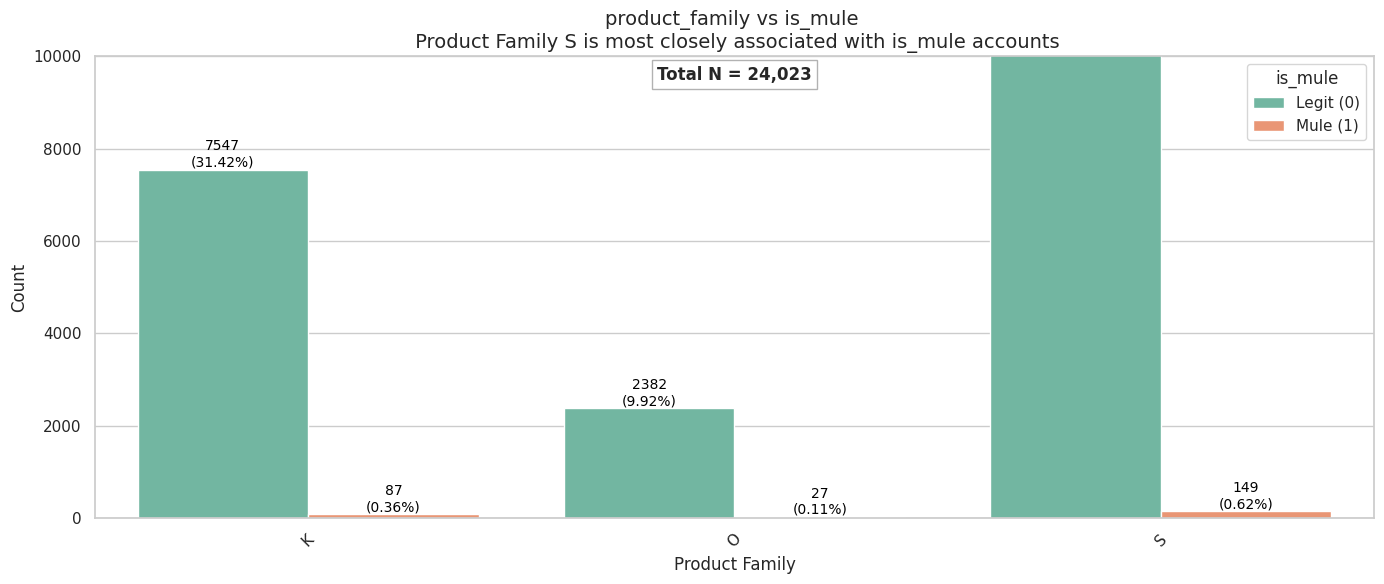

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

ax = sns.countplot(
    data=train,
    x='product_family',
    hue='is_mule',
    palette='Set2'
)

plt.title("product_family vs is_mule \n Product Family S is most closely associated with is_mule accounts", fontsize=14)

plt.xlabel("Product Family")

plt.ylabel("Count")

plt.ylim(0, 10000)

# ---- ADD TOTAL COUNT N ON TOP ----
plt.text(
    0.5, 0.98,
    f'Total N = {len(train):,}',
    transform=plt.gca().transAxes,
    ha='center',
    va='top',
    fontsize=12,
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray')
)

plt.legend(title="is_mule", labels=["Legit (0)", "Mule (1)"])

plt.xticks(rotation=45)

# ---- ADD COUNT + PERCENTAGE LABELS (skip 0%) ----
total = len(train)

for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / total

    # Skip if percentage rounds to 0.00%
    if pct < 0.01:
        continue

    ax.annotate(
        f'{count}\n({pct:.2f}%)',
        (p.get_x() + p.get_width()/2., count),
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.tight_layout()

plt.show()

#2.3 changing `plt.ylim()` shows better insights on is_mule breakup by product family as shown in adjoining plot

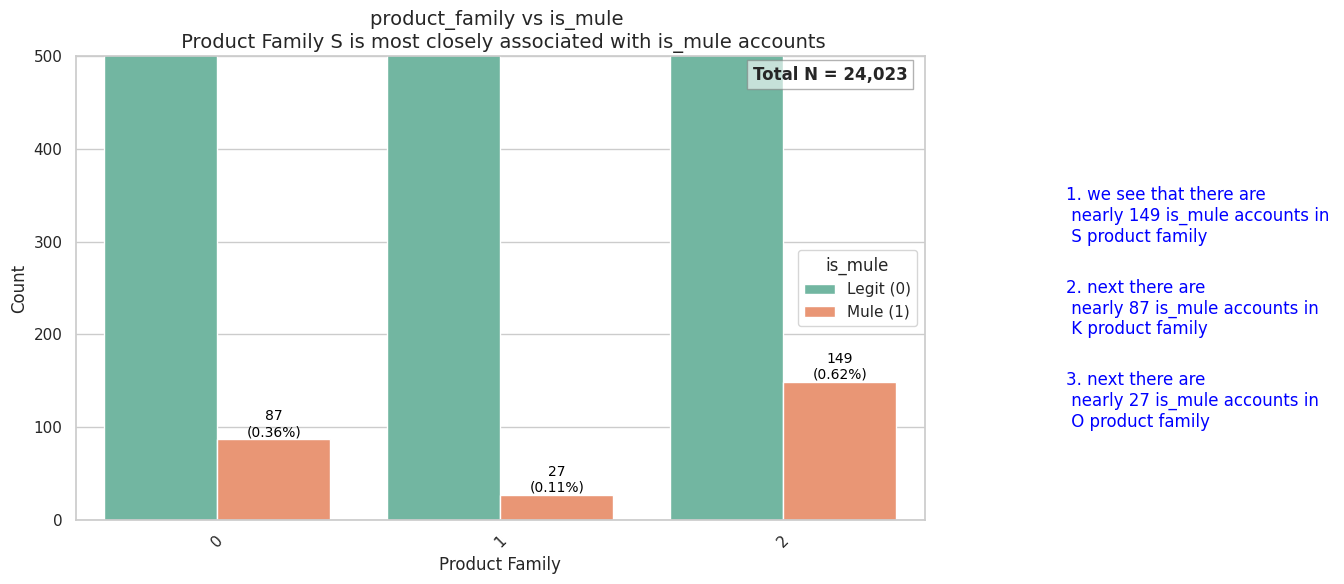

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

ax = sns.countplot(
    data=train,
    x='product_family',
    hue='is_mule',
    palette='Set2'
)

plt.title("product_family vs is_mule \n Product Family S is most closely associated with is_mule accounts", fontsize=14)

plt.xlabel("Product Family")

plt.ylabel("Count")

# Add total N to plot
plt.text(
    0.98, 0.98,
    f'Total N = {len(train):,}',
    transform=plt.gca().transAxes,
    ha='right',
    va='top',
    fontsize=12,
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray')
)

plt.ylim(0, 500)

plt.text(x=3,y=300,s="1. we see that there are \n nearly 149 is_mule accounts in \n S product family",size=12, color ="blue")
plt.text(x=3,y=200,s="2. next there are \n nearly 87 is_mule accounts in \n K product family",size=12,color = "blue")
plt.text(x=3,y=100,s="3. next there are \n nearly 27 is_mule accounts in \n O product family",size=12,color = "blue")

plt.legend(title="is_mule", labels=["Legit (0)", "Mule (1)"])

plt.xticks(rotation=45)

# ---- ADD COUNT + PERCENTAGE LABELS ----
total = len(train)

for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / total

    if pct < 0.01:
        continue

    ax.annotate(
        f'{count}\n({pct:.2f}%)',
        (p.get_x() + p.get_width()/2., count),
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.tight_layout()

plt.show()

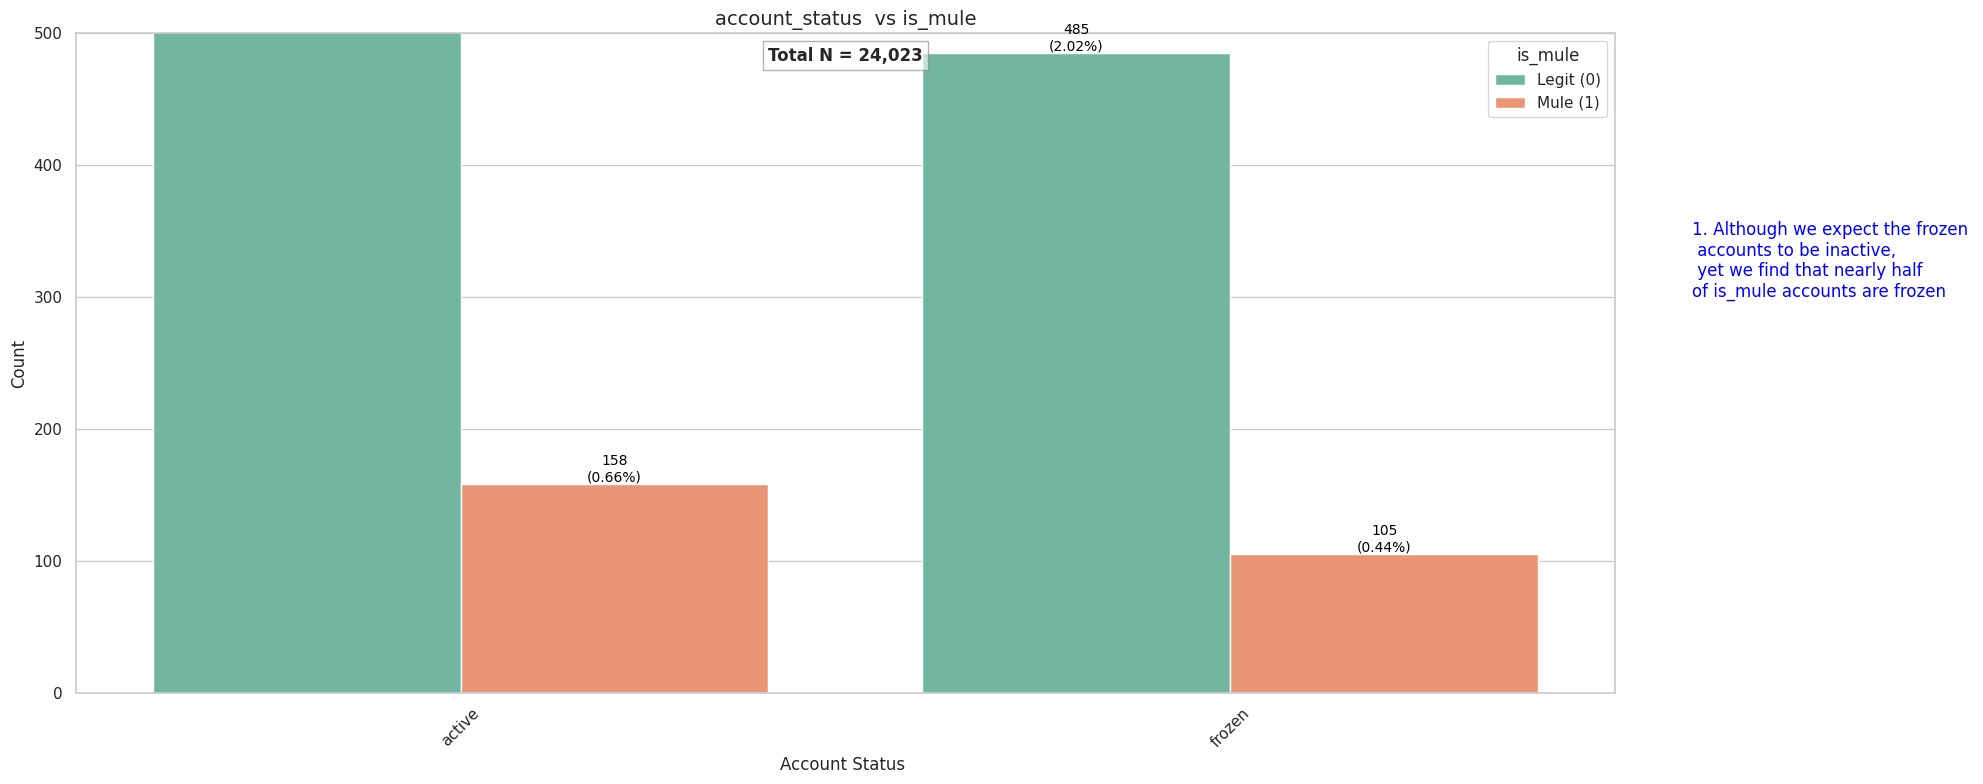

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,8))

ax = sns.countplot(
    data=train,
    x='account_status',
    hue='is_mule',
    palette='Set2'
)

plt.title("account_status  vs is_mule", fontsize=14)

plt.xlabel("Account Status ")

plt.ylabel("Count")

plt.ylim(0, 500)

# ---- ADD TOTAL COUNT N ON TOP ----
plt.text(
    0.5, 0.98,
    f'Total N = {len(train):,}',
    transform=plt.gca().transAxes,
    ha='center',
    va='top',
    fontsize=12,
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray')
)

plt.legend(title="is_mule", labels=["Legit (0)", "Mule (1)"])

plt.xticks(rotation=45)

# ---- ADD COUNT + PERCENTAGE LABELS (skip 0%) ----
total = len(train)

for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / total

    # Skip if percentage rounds to 0.00%
    if pct < 0.01:
        continue

    ax.annotate(
        f'{count}\n({pct:.2f}%)',
        (p.get_x() + p.get_width()/2., count),
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.text(x=1.6,y=300,s="1. Although we expect the frozen \n accounts to be inactive, \n yet we find that nearly half \nof is_mule accounts are frozen",size=12, color ="blue")

plt.tight_layout()

plt.show()

#2.4 Branch distribution only among frozen accounts

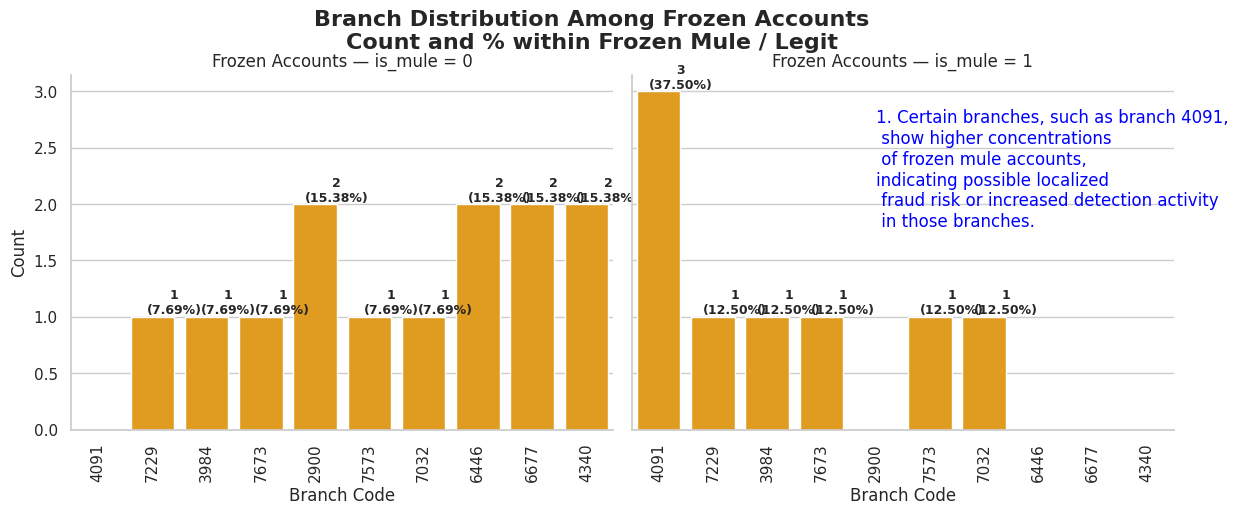

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter frozen accounts
frozen_df = train[train['account_status'] == 'frozen']

# Select top 10 branches for clarity
top_branches = (
    frozen_df['branch_code']
    .value_counts()
    .head(10)
    .index
)

frozen_df = frozen_df[frozen_df['branch_code'].isin(top_branches)]

# Create FacetGrid
g = sns.FacetGrid(
    data=frozen_df,
    col="is_mule",
    height=5,
    aspect=1.2
)

g.map_dataframe(
    sns.countplot,
    x="branch_code",
    order=top_branches,
    color="orange"
)

g.set_axis_labels("Branch Code", "Count")
g.set_titles("Frozen Accounts — is_mule = {col_name}")

g.fig.suptitle(
    "Branch Distribution Among Frozen Accounts\nCount and % within Frozen Mule / Legit",
    fontsize=16,
    fontweight="bold"
)

g.fig.subplots_adjust(top=0.85)

# ---- ADD COUNT + % LABELS ----
for ax, (is_mule_value, subset) in zip(g.axes.flat, frozen_df.groupby("is_mule")):

    total = len(subset)

    for p in ax.patches:

        count = int(p.get_height())

        if count == 0:
            continue

        pct = 100 * count / total

        ax.annotate(
            f'{count}\n({pct:.2f}%)',
            (p.get_x() + p.get_width(), count),
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

# Rotate x labels
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=90)

plt.text(x=4,y=1.8,s="1. Certain branches, such as branch 4091,\n show higher concentrations\n of frozen mule accounts, \nindicating possible localized\n fraud risk or increased detection activity\n in those branches.",color="blue")
plt.show()

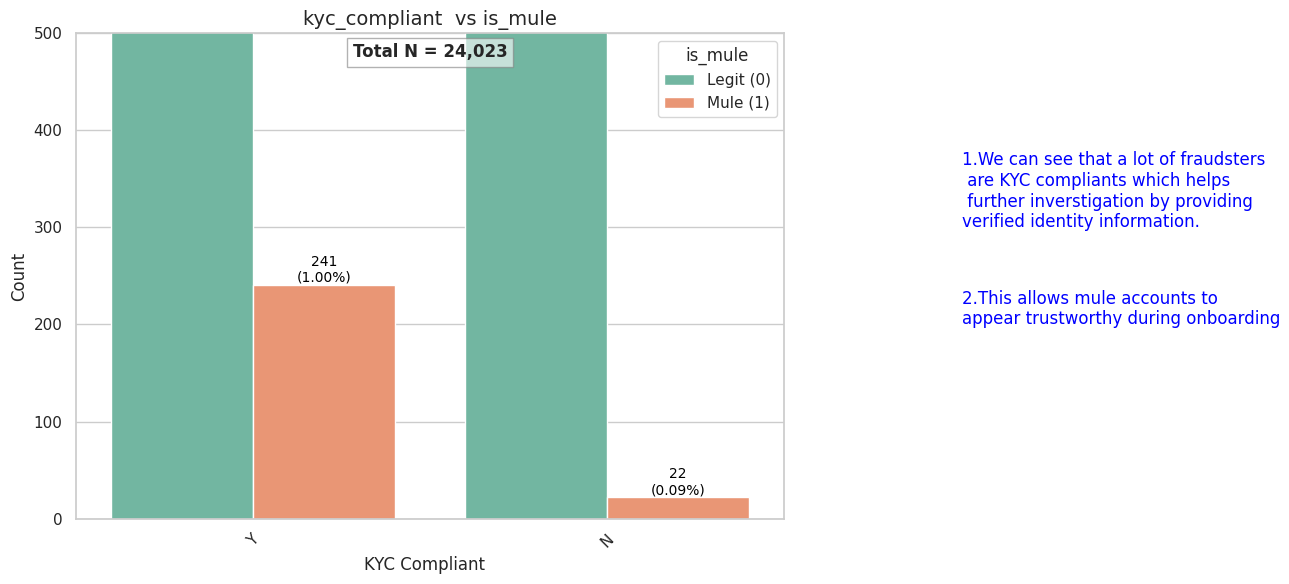

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

ax = sns.countplot(
    data=train,
    x='kyc_compliant',
    hue='is_mule',
    palette='Set2'
)

plt.title("kyc_compliant  vs is_mule", fontsize=14)

plt.xlabel("KYC Compliant  ")

plt.ylabel("Count")

plt.ylim(0, 500)

# ---- ADD TOTAL COUNT N ON TOP ----
plt.text(
    0.5, 0.98,
    f'Total N = {len(train):,}',
    transform=plt.gca().transAxes,
    ha='center',
    va='top',
    fontsize=12,
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray')
)

plt.legend(title="is_mule", labels=["Legit (0)", "Mule (1)"])

plt.xticks(rotation=45)

# ---- ADD COUNT + PERCENTAGE LABELS (skip 0%) ----
total = len(train)

for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / total

    # Skip if percentage rounds to 0.00%
    if pct < 0.01:
        continue

    ax.annotate(
        f'{count}\n({pct:.2f}%)',
        (p.get_x() + p.get_width()/2., count),
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.text(x=2,y= 300, s="1.We can see that a lot of fraudsters\n are KYC compliants which helps\n further inverstigation by providing \nverified identity information.",color="blue")
plt.text(x=2,y= 200, s="2.This allows mule accounts to \nappear trustworthy during onboarding",color="blue")
plt.tight_layout()

plt.show()

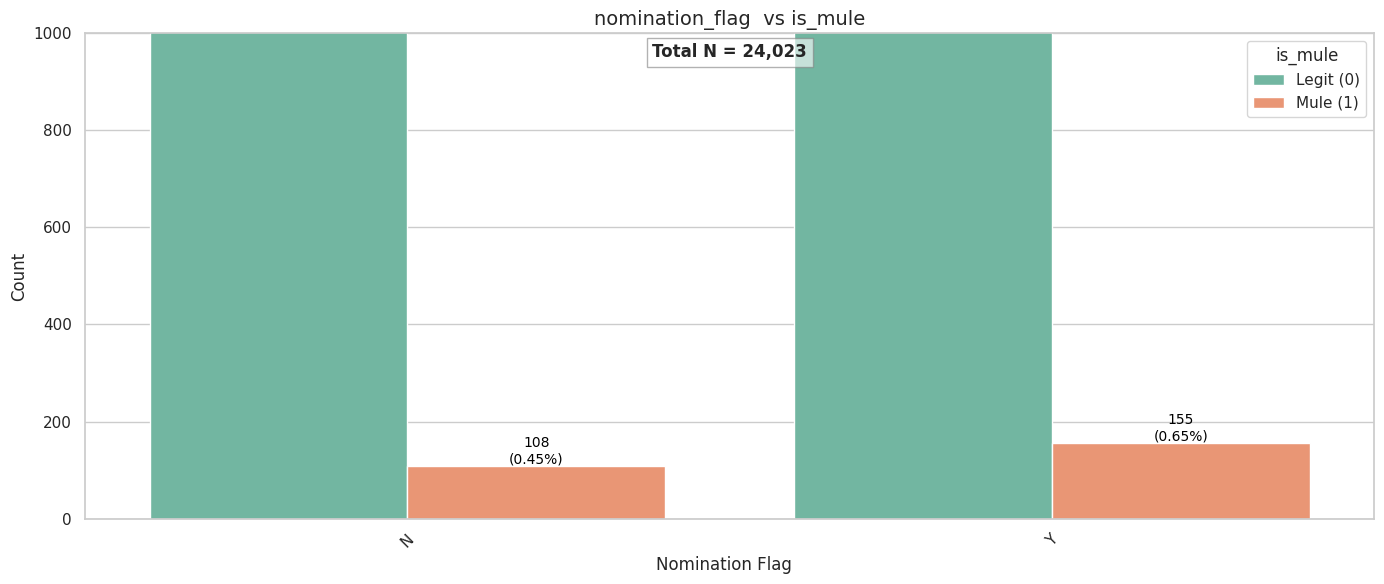

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

ax = sns.countplot(
    data=train,
    x='nomination_flag',
    hue='is_mule',
    palette='Set2'
)

plt.title("nomination_flag  vs is_mule", fontsize=14)

plt.xlabel("Nomination Flag  ")

plt.ylabel("Count")

plt.ylim(0, 1000)

# ---- ADD TOTAL COUNT N ON TOP ----
plt.text(
    0.5, 0.98,
    f'Total N = {len(train):,}',
    transform=plt.gca().transAxes,
    ha='center',
    va='top',
    fontsize=12,
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray')
)

plt.legend(title="is_mule", labels=["Legit (0)", "Mule (1)"])

plt.xticks(rotation=45)

# ---- ADD COUNT + PERCENTAGE LABELS (skip 0%) ----
total = len(train)

for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / total

    # Skip if percentage rounds to 0.00%
    if pct < 0.01:
        continue

    ax.annotate(
        f'{count}\n({pct:.2f}%)',
        (p.get_x() + p.get_width()/2., count),
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.tight_layout()

plt.show()

#2.5 Breakup of Nomination Flag by Product Family using is_mule as filter

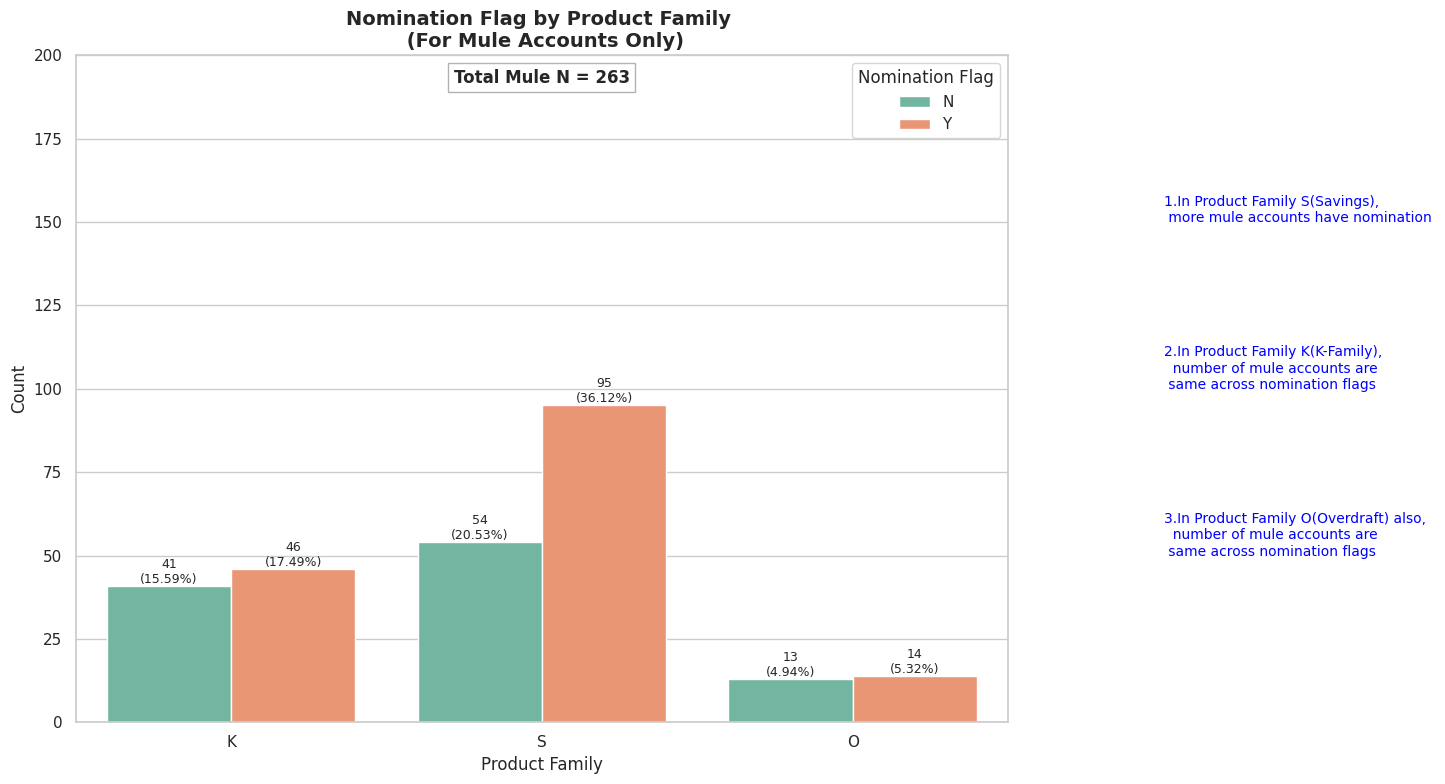

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter only mule accounts
train_mule = train[train["is_mule"] == 1]

plt.figure(figsize=(15,8))

ax = sns.countplot(
    data=train_mule,
    x="product_family",
    hue="nomination_flag",
    palette="Set2"
)

plt.ylim(0, 200)

plt.title(
    "Nomination Flag by Product Family \n (For Mule Accounts Only)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Product Family")
plt.ylabel("Count")

# Add total mule count
plt.text(
    0.5, 0.98,
    f"Total Mule N = {len(train_mule):,}",
    transform=plt.gca().transAxes,
    ha="center",
    va="top",
    fontsize=12,
    fontweight="bold",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="gray")
)

plt.legend(title="Nomination Flag")

# ---- ADD COUNT + % LABELS (within mule only) ----
total = len(train_mule)

for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / total

    if count == 0:
        continue

    ax.annotate(
        f"{count}\n({pct:.2f}%)",
        (p.get_x() + p.get_width()/2., count),
        ha="center",
        va="bottom",
        fontsize=9
    )
plt.text(x=3,y=150,s="1.In Product Family S(Savings),\n more mule accounts have nomination ", size=10,color='blue')
plt.text(x=3,y=100,s="2.In Product Family K(K-Family),\n  number of mule accounts are \n same across nomination flags", size=10,color='blue')
plt.text(x=3,y=50,s="3.In Product Family O(Overdraft) also,\n  number of mule accounts are \n same across nomination flags", size=10,color='blue')

plt.tight_layout()
plt.show()

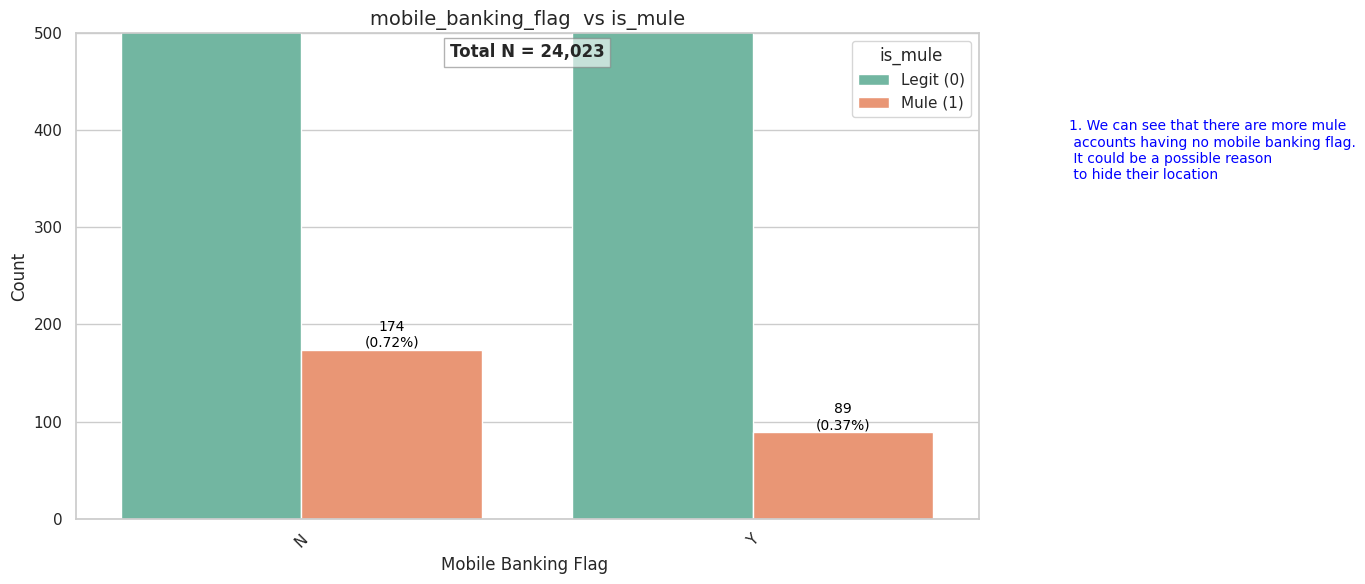

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

ax = sns.countplot(
    data=train,
    x='mobile_banking_flag',
    hue='is_mule',
    palette='Set2'
)

plt.title("mobile_banking_flag  vs is_mule", fontsize=14)

plt.xlabel("Mobile Banking Flag ")

plt.ylabel("Count")

plt.ylim(0, 500)

# ---- ADD TOTAL COUNT N ON TOP ----
plt.text(
    0.5, 0.98,
    f'Total N = {len(train):,}',
    transform=plt.gca().transAxes,
    ha='center',
    va='top',
    fontsize=12,
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray')
)

plt.legend(title="is_mule", labels=["Legit (0)", "Mule (1)"])

plt.xticks(rotation=45)

# ---- ADD COUNT + PERCENTAGE LABELS (skip 0%) ----
total = len(train)

for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / total

    # Skip if percentage rounds to 0.00%
    if pct < 0.01:
        continue

    ax.annotate(
        f'{count}\n({pct:.2f}%)',
        (p.get_x() + p.get_width()/2., count),
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )
plt.text(x=1.7,y=350,s="1. We can see that there are more mule \n accounts having no mobile banking flag.\n It could be a possible reason \n to hide their location",size=10,color='blue')

plt.tight_layout()

plt.show()

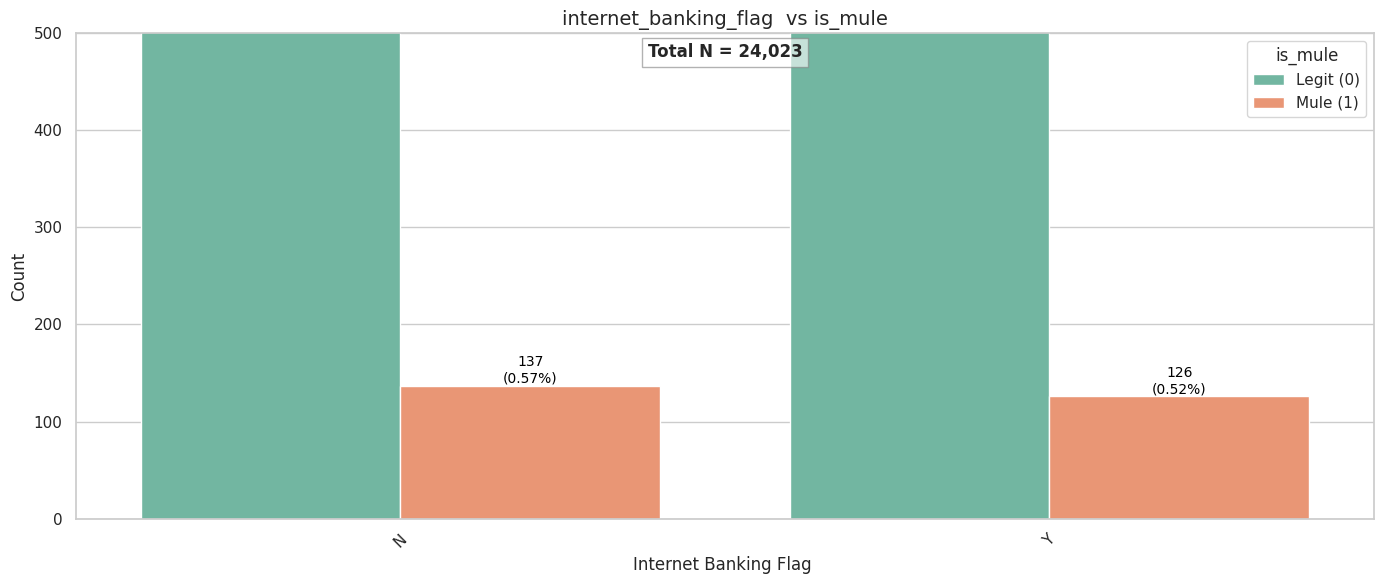

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

ax = sns.countplot(
    data=train,
    x='internet_banking_flag',
    hue='is_mule',
    palette='Set2'
)

plt.title("internet_banking_flag  vs is_mule", fontsize=14)

plt.xlabel("Internet Banking Flag ")

plt.ylabel("Count")

plt.ylim(0, 500)

# ---- ADD TOTAL COUNT N ON TOP ----
plt.text(
    0.5, 0.98,
    f'Total N = {len(train):,}',
    transform=plt.gca().transAxes,
    ha='center',
    va='top',
    fontsize=12,
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray')
)

plt.legend(title="is_mule", labels=["Legit (0)", "Mule (1)"])

plt.xticks(rotation=45)

# ---- ADD COUNT + PERCENTAGE LABELS (skip 0%) ----
total = len(train)

for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / total

    # Skip if percentage rounds to 0.00%
    if pct < 0.01:
        continue

    ax.annotate(
        f'{count}\n({pct:.2f}%)',
        (p.get_x() + p.get_width()/2., count),
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.tight_layout()

plt.show()

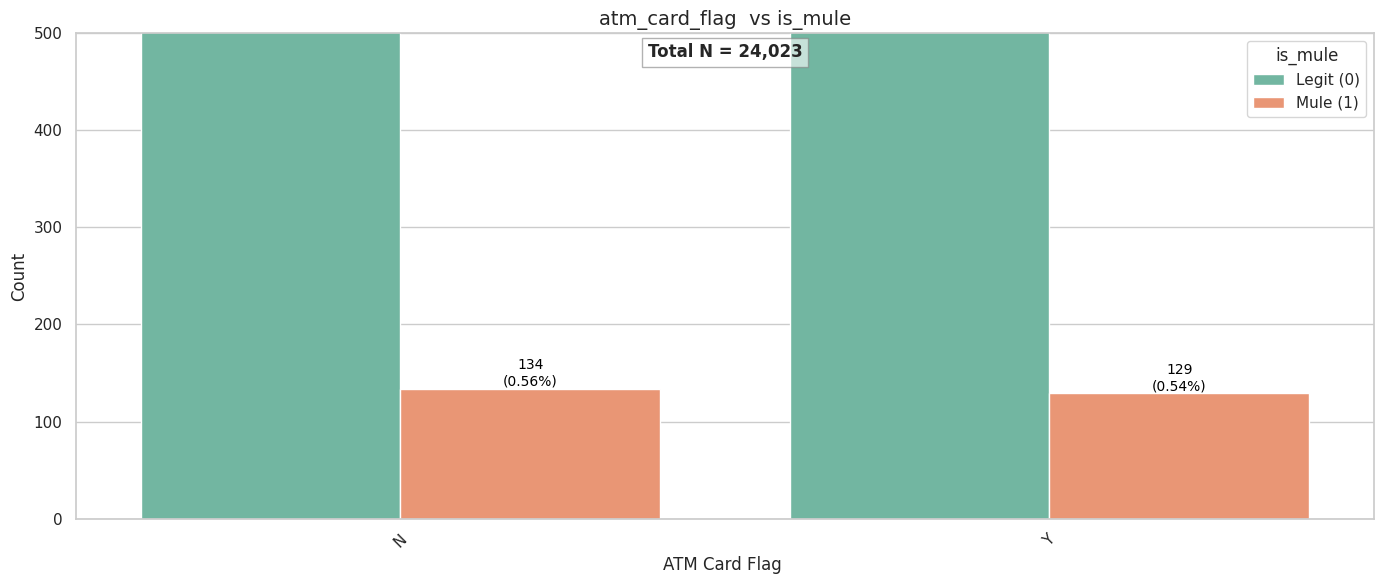

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

ax = sns.countplot(
    data=train,
    x='atm_card_flag',
    hue='is_mule',
    palette='Set2'
)

plt.title("atm_card_flag  vs is_mule", fontsize=14)

plt.xlabel("ATM Card Flag ")

plt.ylabel("Count")

plt.ylim(0, 500)

# ---- ADD TOTAL COUNT N ON TOP ----
plt.text(
    0.5, 0.98,
    f'Total N = {len(train):,}',
    transform=plt.gca().transAxes,
    ha='center',
    va='top',
    fontsize=12,
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray')
)

plt.legend(title="is_mule", labels=["Legit (0)", "Mule (1)"])

plt.xticks(rotation=45)

# ---- ADD COUNT + PERCENTAGE LABELS (skip 0%) ----
total = len(train)

for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / total

    # Skip if percentage rounds to 0.00%
    if pct < 0.01:
        continue

    ax.annotate(
        f'{count}\n({pct:.2f}%)',
        (p.get_x() + p.get_width()/2., count),
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.tight_layout()

plt.show()

# A.0 APPENDIX

## A.1 Remaining barplots for categorical variables


In [ ]:
cat_cols_filtered = [
    'cheque_allowed',
    'cheque_availed',
    'rural_branch',
    'pan_available',
    'aadhaar_available',
    'passport_available',
    'demat_flag',
    'credit_card_flag',
    'fastag_flag'
]

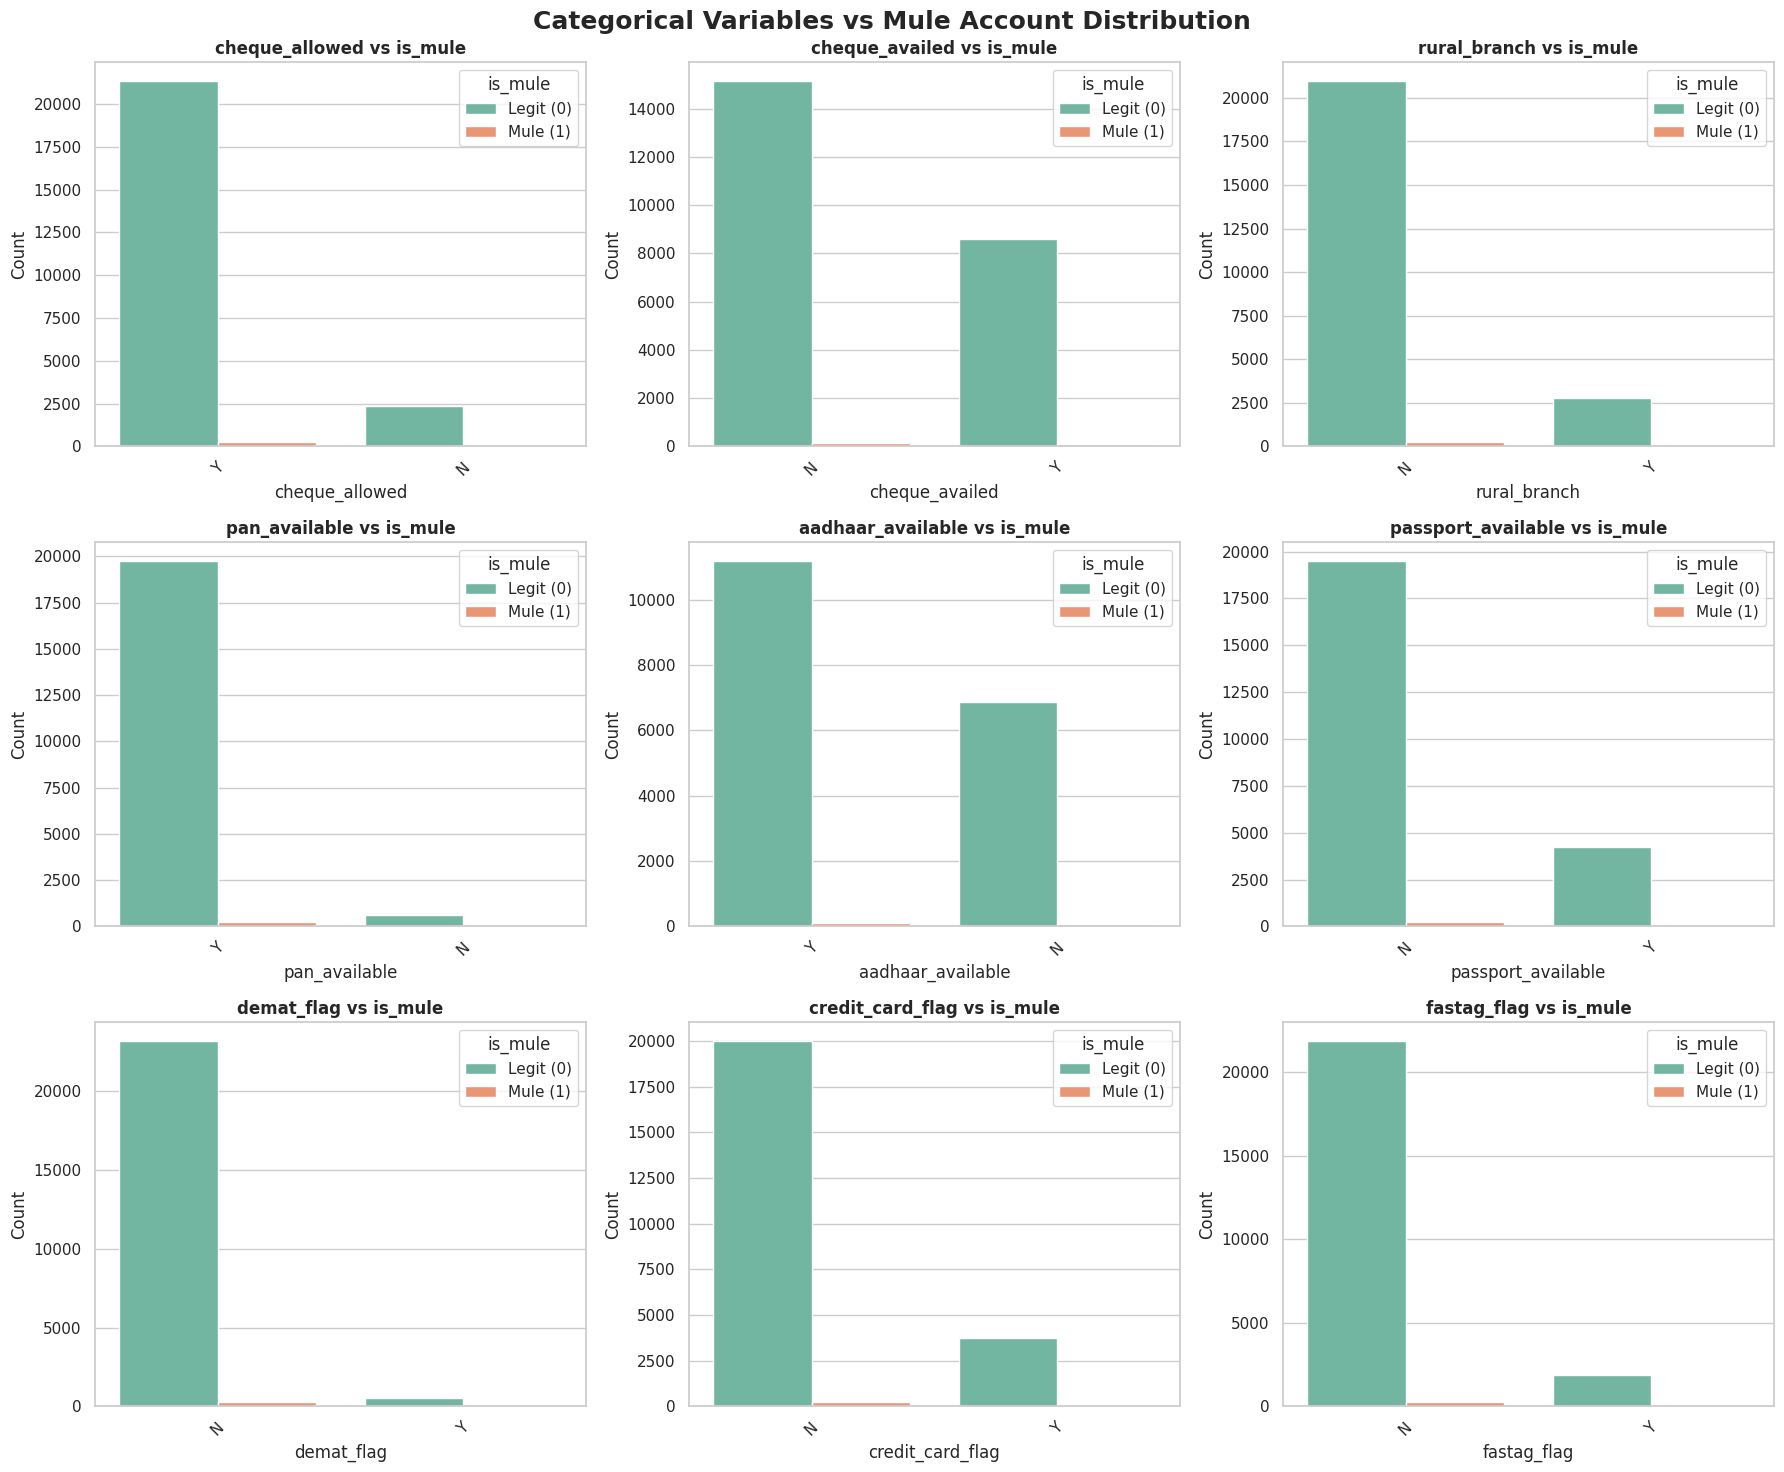

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# subplot grid size
n_cols = 3
n_rows = (len(cat_cols_filtered) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

# Create each subplot
for i, col in enumerate(cat_cols_filtered):

    ax = axes[i]

    sns.countplot(
        data=train,
        x=col,
        hue='is_mule',
        palette='Set2',
        ax=ax
    )

    ax.set_title(f"{col} vs is_mule", fontsize=12, fontweight='bold')

    ax.set_xlabel(col)
    ax.set_ylabel("Count")

    ax.legend(title="is_mule", labels=["Legit (0)", "Mule (1)"])

    ax.tick_params(axis='x', rotation=45)

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Categorical Variables vs Mule Account Distribution",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

#3 Histograms for Numerical Variables

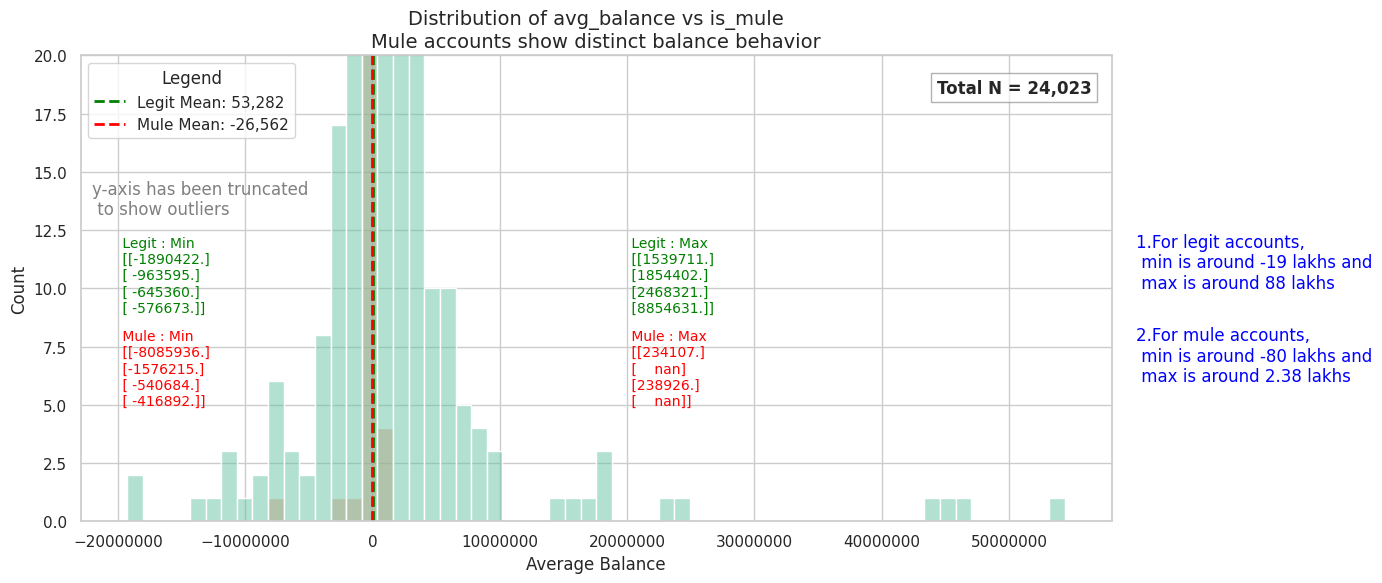

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# set avg bal to actaul nos. avoid scitific notation
plt.figure(figsize=(14,6))

np.set_printoptions(suppress=True)
# Plot histogram with  so mule is visible
ax = sns.histplot(
    data=train,
    x='avg_balance',
    hue='is_mule',
    bins=60,
    stat='count',
    common_norm=False,
    palette='Set2',
    alpha=0.5
)

plt.ylim(0,20)

# Calculate means
mean_legit = train[train['is_mule']==0]['avg_balance'].mean()
mean_mule = train[train['is_mule']==1]['avg_balance'].mean()

min_legit = sorted(train[train['is_mule']==0]['avg_balance'].round())[0:4]
min_legit = np.vstack(min_legit)

max_legit = sorted(train[train['is_mule']==0]['avg_balance'].round())[-4:]
max_legit = np.vstack(max_legit)

min_mule = sorted(train[train['is_mule']==1]['avg_balance'].round())[0:4]
min_mule = np.vstack(min_mule)

max_mule = sorted(train[train['is_mule']==1]['avg_balance'].round())[-4:]
max_mule = np.vstack(max_mule)

# Add mean lines
plt.axvline(mean_legit, color='green', linestyle='--', linewidth=2,
            label=f'Legit Mean: {mean_legit:,.0f}')

plt.axvline(mean_mule, color='red', linestyle='--', linewidth=2,
            label=f'Mule Mean: {mean_mule:,.0f}')

# Add total count
plt.text(
    0.98, 0.95,
    f'Total N = {len(train):,}',
    transform=plt.gca().transAxes,
    ha='right',
    va='top',
    fontsize=12,
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray')
)

plt.text(x =  -20_000_000, y = 9, s = f' Legit : Min\n {min_legit}', size = 10, color = 'green' )
plt.text(x =  20_000_000, y = 9, s = f' Legit : Max\n {max_legit}', size = 10, color = 'green' )
plt.text(x= -22_000_000, y=13, s="y-axis has been truncated \n to show outliers",ha="left",va="bottom", color = 'grey')
plt.text(x =  -20_000_000, y = 5, s = f' Mule : Min\n {min_mule}', size = 10, color = 'red' )
plt.text(x =  20_000_000, y = 5, s = f' Mule : Max\n {max_mule}', size = 10, color = 'red' )

plt.text(x=60_000_000,y=10,s="1.For legit accounts,\n min is around -19 lakhs and\n max is around 88 lakhs",size = 12,color = 'blue')
plt.text(x=60_000_000,y=6,s="2.For mule accounts,\n min is around -80 lakhs and\n max is around 2.38 lakhs",size = 12,color = 'blue')

# Labels and title
plt.title(
    "Distribution of avg_balance vs is_mule\nMule accounts show distinct balance behavior",
    fontsize=14
)

plt.xlabel("Average Balance")

plt.ylabel("Count")
plt.ticklabel_format(style='plain', axis='both')
plt.legend(title="Legend")

plt.tight_layout()

plt.show()

/tmp/ipython-input-1335046018.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


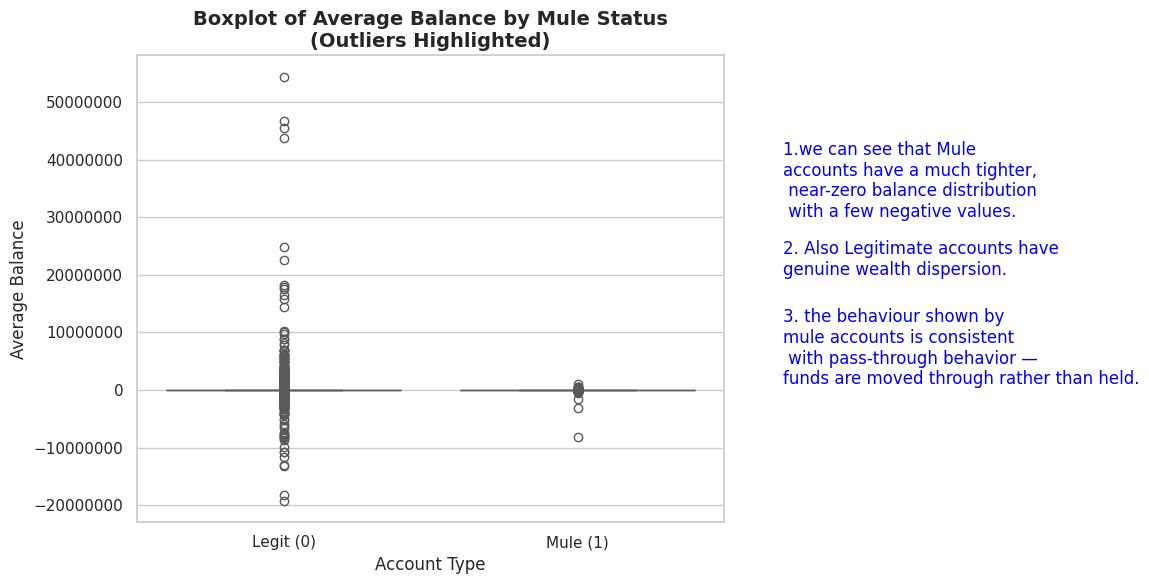

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

ax = sns.boxplot(
    data=train,
    x='is_mule',
    y='avg_balance',
    palette='Set2',
    showfliers=True   # ensures outliers are visible
)

plt.title(
    "Boxplot of Average Balance by Mule Status\n(Outliers Highlighted)",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Account Type")
plt.ylabel("Average Balance")

plt.xticks([0,1], ["Legit (0)", "Mule (1)"])

plt.text(x=1.7,y=30000000,s="1.we can see that Mule \naccounts have a much tighter,\n near-zero balance distribution\n with a few negative values.",color="blue")
plt.text(x=1.7,y=20000000,s="2. Also Legitimate accounts have \ngenuine wealth dispersion.",color="blue")
plt.text(x=1.7,y=1000000,s="3. the behaviour shown by \nmule accounts is consistent\n with pass-through behavior —\nfunds are moved through rather than held.",color="blue")

plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

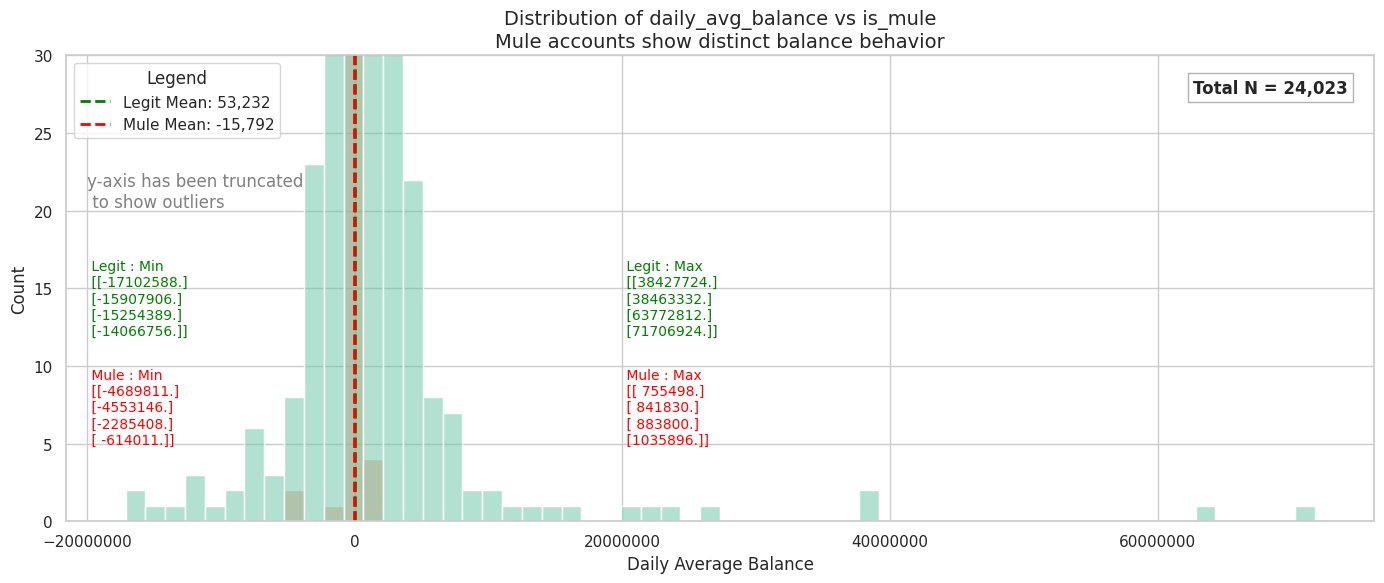

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# set avg bal to actaul nos. avoid scitific notation
plt.figure(figsize=(14,6))

np.set_printoptions(suppress=True)
# Plot histogram with  so mule is visible
ax = sns.histplot(
    data=train,
    x='daily_avg_balance',
    hue='is_mule',
    bins=60,
    stat='count',
    common_norm=False,
    palette='Set2',
    alpha=0.5
)

plt.ylim(0,30)

# Calculate means
mean_legit = train[train['is_mule']==0]['daily_avg_balance'].mean()
mean_mule = train[train['is_mule']==1]['daily_avg_balance'].mean()

min_legit = sorted(train[train['is_mule']==0]['daily_avg_balance'].round())[0:4]
min_legit = np.vstack(min_legit)

max_legit = sorted(train[train['is_mule']==0]['daily_avg_balance'].round())[-4:]
max_legit = np.vstack(max_legit)

min_mule = sorted(train[train['is_mule']==1]['daily_avg_balance'].round())[0:4]
min_mule = np.vstack(min_mule)

max_mule = sorted(train[train['is_mule']==1]['daily_avg_balance'].round())[-4:]
max_mule = np.vstack(max_mule)

# Add mean lines
plt.axvline(mean_legit, color='green', linestyle='--', linewidth=2,
            label=f'Legit Mean: {mean_legit:,.0f}')

plt.axvline(mean_mule, color='red', linestyle='--', linewidth=2,
            label=f'Mule Mean: {mean_mule:,.0f}')

# Add total count
plt.text(
    0.98, 0.95,
    f'Total N = {len(train):,}',
    transform=plt.gca().transAxes,
    ha='right',
    va='top',
    fontsize=12,
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray')
)

plt.text(x =  -20_000_000, y = 12, s = f' Legit : Min\n {min_legit}', size = 10, color = 'green' )
plt.text(x =  20_000_000, y = 12, s = f' Legit : Max\n {max_legit}', size = 10, color = 'green' )
plt.text(x= -20_000_000, y=20, s="y-axis has been truncated \n to show outliers",ha="left",va="bottom", color = 'grey')
plt.text(x =  -20_000_000, y = 5, s = f' Mule : Min\n {min_mule}', size = 10, color = 'red' )
plt.text(x =  20_000_000, y = 5, s = f' Mule : Max\n {max_mule}', size = 10, color = 'red' )

# Labels and title
plt.title(
    "Distribution of daily_avg_balance vs is_mule\nMule accounts show distinct balance behavior",
    fontsize=14
)

plt.xlabel("Daily Average Balance")

plt.ylabel("Count")
plt.ticklabel_format(style='plain', axis='both')
plt.legend(title="Legend")

plt.tight_layout()

plt.show()

/tmp/ipython-input-3733223476.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


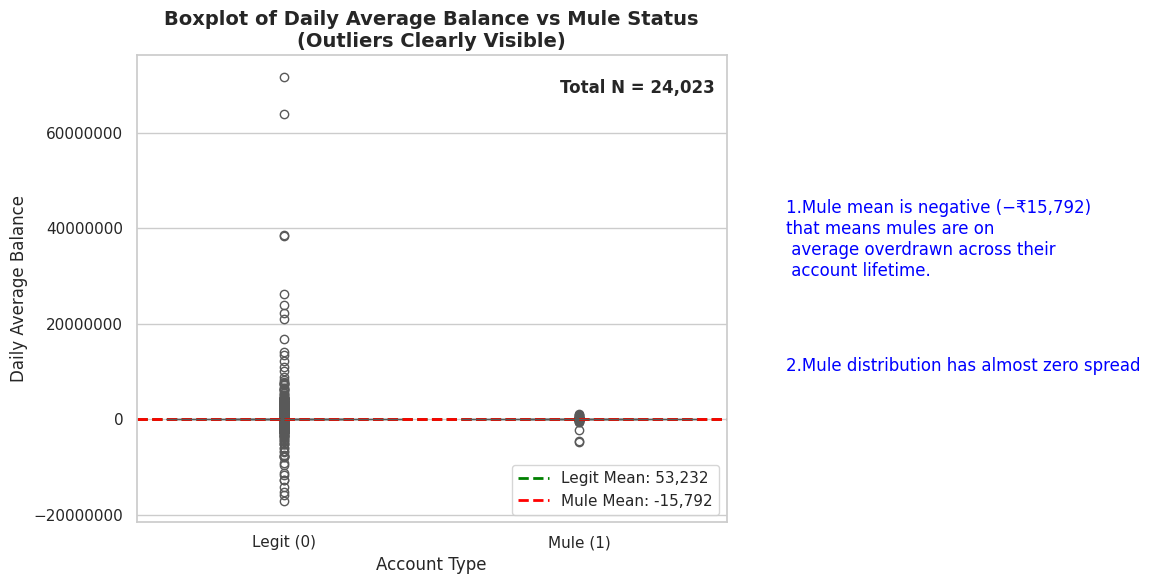

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

ax = sns.boxplot(
    data=train,
    x='is_mule',
    y='daily_avg_balance',
    palette='Set2',
    showfliers=True
)

# Add means
mean_legit = train[train['is_mule']==0]['daily_avg_balance'].mean()
mean_mule = train[train['is_mule']==1]['daily_avg_balance'].mean()

plt.axhline(mean_legit, color='green', linestyle='--', linewidth=2,
            label=f'Legit Mean: {mean_legit:,.0f}')

plt.axhline(mean_mule, color='red', linestyle='--', linewidth=2,
            label=f'Mule Mean: {mean_mule:,.0f}')

# Total count
plt.text(
    0.98, 0.95,
    f'Total N = {len(train):,}',
    transform=plt.gca().transAxes,
    ha='right',
    va='top',
    fontsize=12,
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.6)
)

plt.title(
    "Boxplot of Daily Average Balance vs Mule Status\n(Outliers Clearly Visible)",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Account Type")
plt.ylabel("Daily Average Balance")

plt.xticks([0,1], ["Legit (0)", "Mule (1)"])

plt.text(x=1.7,y=30000000,s="1.Mule mean is negative (−₹15,792)\nthat means mules are on\n average overdrawn across their\n account lifetime.",color="blue")
plt.text(x=1.7,y=10000000,s="2.Mule distribution has almost zero spread",color="blue")

plt.ticklabel_format(style='plain', axis='y')

plt.legend()

plt.tight_layout()
plt.show()

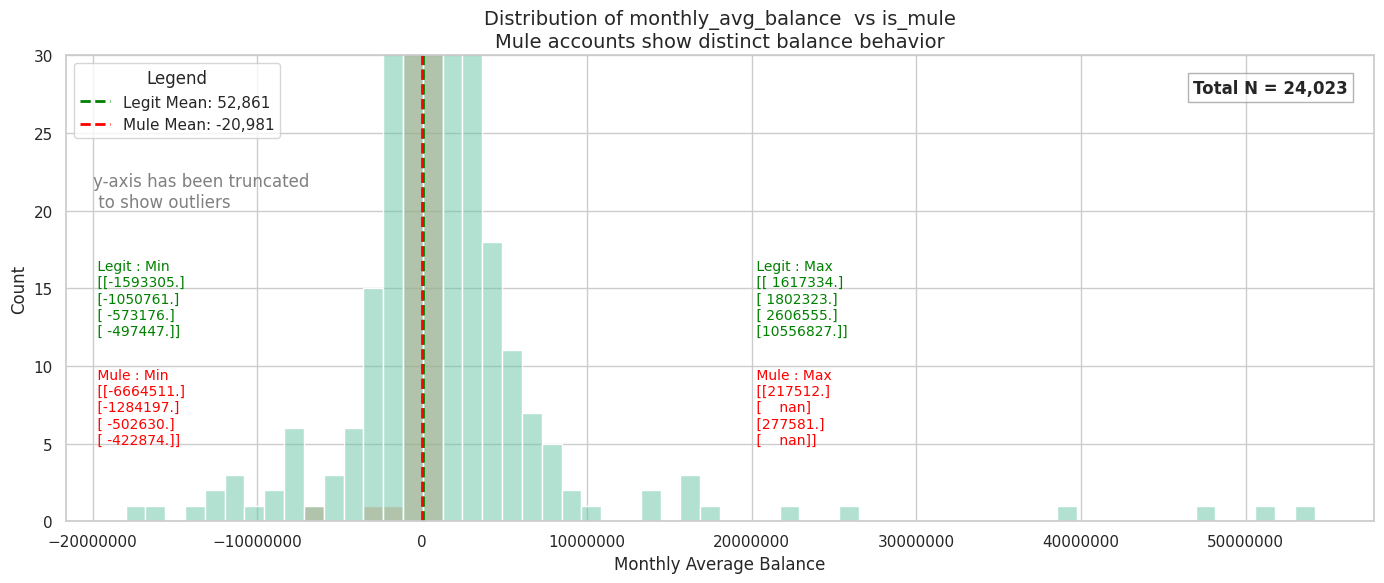

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# set avg bal to actaul nos. avoid scitific notation
plt.figure(figsize=(14,6))

np.set_printoptions(suppress=True)
# Plot histogram with  so mule is visible
ax = sns.histplot(
    data=train,
    x='monthly_avg_balance',
    hue='is_mule',
    bins=60,
    stat='count',
    common_norm=False,
    palette='Set2',
    alpha=0.5
)

plt.ylim(0,30)

# Calculate means
mean_legit = train[train['is_mule']==0]['monthly_avg_balance'].mean()
mean_mule = train[train['is_mule']==1]['monthly_avg_balance'].mean()

min_legit = sorted(train[train['is_mule']==0]['monthly_avg_balance'].round())[0:4]
min_legit = np.vstack(min_legit)

max_legit = sorted(train[train['is_mule']==0]['monthly_avg_balance'].round())[-4:]
max_legit = np.vstack(max_legit)

min_mule = sorted(train[train['is_mule']==1]['monthly_avg_balance'].round())[0:4]
min_mule = np.vstack(min_mule)

max_mule = sorted(train[train['is_mule']==1]['monthly_avg_balance'].round())[-4:]
max_mule = np.vstack(max_mule)

# Add mean lines
plt.axvline(mean_legit, color='green', linestyle='--', linewidth=2,
            label=f'Legit Mean: {mean_legit:,.0f}')

plt.axvline(mean_mule, color='red', linestyle='--', linewidth=2,
            label=f'Mule Mean: {mean_mule:,.0f}')

# Add total count
plt.text(
    0.98, 0.95,
    f'Total N = {len(train):,}',
    transform=plt.gca().transAxes,
    ha='right',
    va='top',
    fontsize=12,
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray')
)

plt.text(x =  -20_000_000, y = 12, s = f' Legit : Min\n {min_legit}', size = 10, color = 'green' )
plt.text(x =  20_000_000, y = 12, s = f' Legit : Max\n {max_legit}', size = 10, color = 'green' )
plt.text(x= -20_000_000, y=20, s="y-axis has been truncated \n to show outliers",ha="left",va="bottom", color = 'grey')
plt.text(x =  -20_000_000, y = 5, s = f' Mule : Min\n {min_mule}', size = 10, color = 'red' )
plt.text(x =  20_000_000, y = 5, s = f' Mule : Max\n {max_mule}', size = 10, color = 'red' )

# Labels and title
plt.title(
    "Distribution of monthly_avg_balance  vs is_mule\nMule accounts show distinct balance behavior",
    fontsize=14
)

plt.xlabel("Monthly Average Balance")

plt.ylabel("Count")
plt.ticklabel_format(style='plain', axis='both')
plt.legend(title="Legend")

plt.tight_layout()

plt.show()

/tmp/ipython-input-2531816974.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


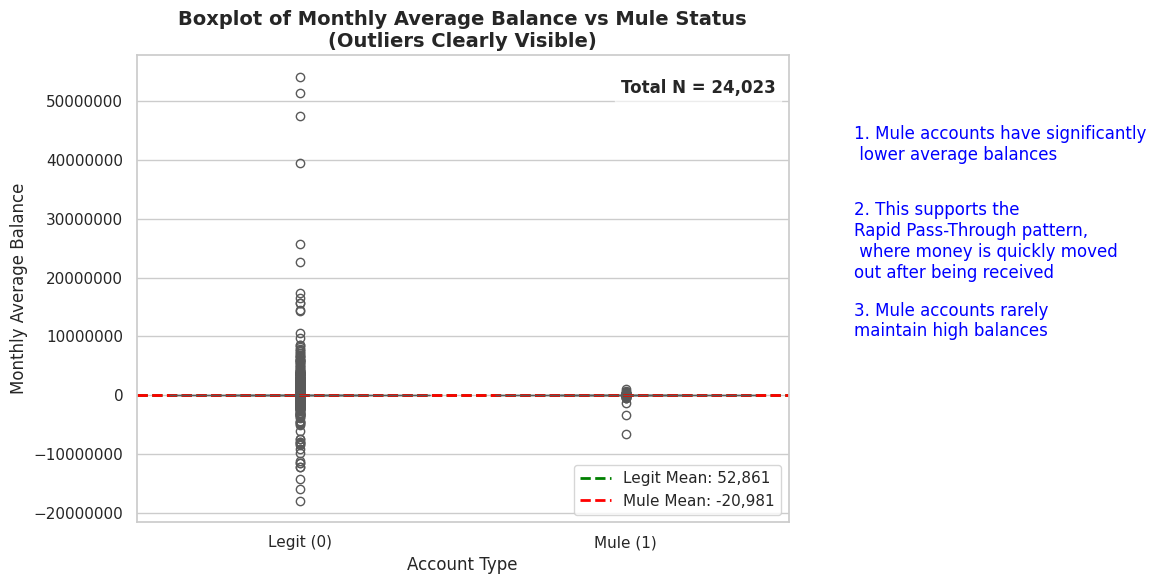

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

ax = sns.boxplot(
    data=train,
    x='is_mule',
    y='monthly_avg_balance',
    palette='Set2',
    showfliers=True
)

# Calculate means
mean_legit = train[train['is_mule']==0]['monthly_avg_balance'].mean()
mean_mule = train[train['is_mule']==1]['monthly_avg_balance'].mean()

# Add mean lines
plt.axhline(mean_legit, color='green', linestyle='--', linewidth=2,
            label=f'Legit Mean: {mean_legit:,.0f}')

plt.axhline(mean_mule, color='red', linestyle='--', linewidth=2,
            label=f'Mule Mean: {mean_mule:,.0f}')

# Add total count
plt.text(
    0.98, 0.95,
    f'Total N = {len(train):,}',
    transform=plt.gca().transAxes,
    ha='right',
    va='top',
    fontsize=12,
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.6)
)

plt.title(
    "Boxplot of Monthly Average Balance vs Mule Status\n(Outliers Clearly Visible)",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Account Type")
plt.ylabel("Monthly Average Balance")

plt.xticks([0,1], ["Legit (0)", "Mule (1)"])

plt.text(x=1.7,y=40000000,s="1. Mule accounts have significantly\n lower average balances",color="blue")
plt.text(x=1.7,y=20000000,s="2. This supports the \nRapid Pass-Through pattern,\n where money is quickly moved \nout after being received",color="blue")
plt.text(x=1.7,y=10000000,s="3. Mule accounts rarely \nmaintain high balances",color="blue")

plt.ticklabel_format(style='plain', axis='y')

plt.legend()

plt.tight_layout()
plt.show()

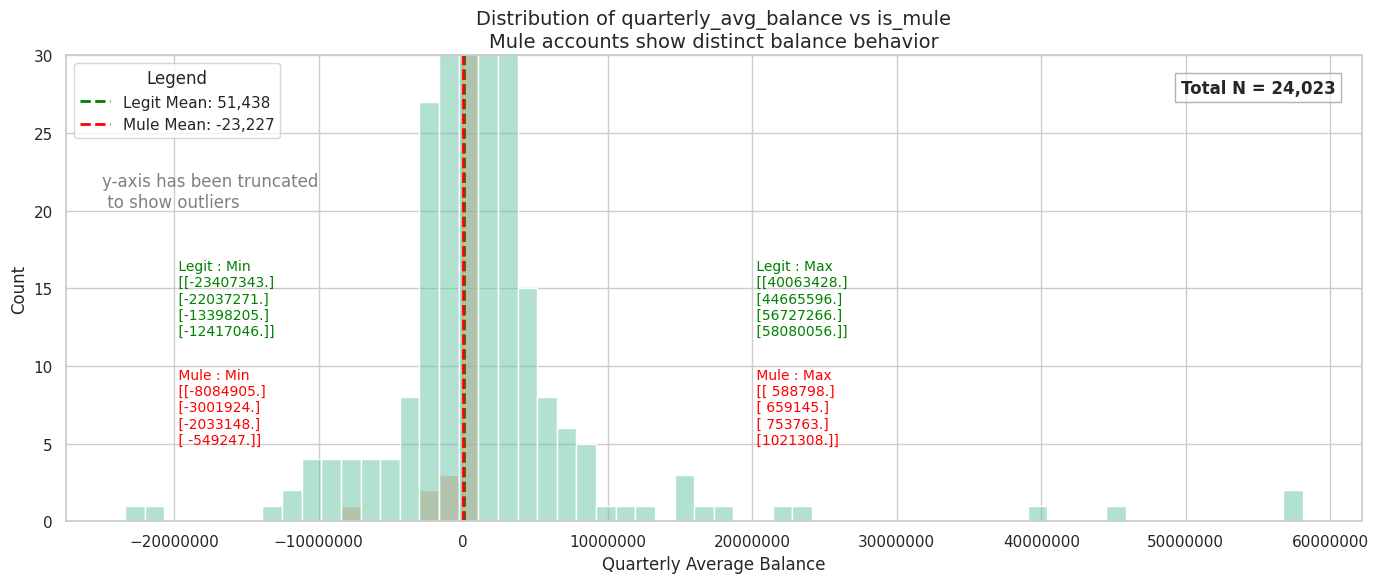

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# set avg bal to actaul nos. avoid scitific notation
plt.figure(figsize=(14,6))

np.set_printoptions(suppress=True)
# Plot histogram with  so mule is visible
ax = sns.histplot(
    data=train,
    x='quarterly_avg_balance',
    hue='is_mule',
    bins=60,
    stat='count',
    common_norm=False,
    palette='Set2',
    alpha=0.5
)

plt.ylim(0,30)

# Calculate means
mean_legit = train[train['is_mule']==0]['quarterly_avg_balance'].mean()
mean_mule = train[train['is_mule']==1]['quarterly_avg_balance'].mean()

min_legit = sorted(train[train['is_mule']==0]['quarterly_avg_balance'].round())[0:4]
min_legit = np.vstack(min_legit)

max_legit = sorted(train[train['is_mule']==0]['quarterly_avg_balance'].round())[-4:]
max_legit = np.vstack(max_legit)

min_mule = sorted(train[train['is_mule']==1]['quarterly_avg_balance'].round())[0:4]
min_mule = np.vstack(min_mule)

max_mule = sorted(train[train['is_mule']==1]['quarterly_avg_balance'].round())[-4:]
max_mule = np.vstack(max_mule)

# Add mean lines
plt.axvline(mean_legit, color='green', linestyle='--', linewidth=2,
            label=f'Legit Mean: {mean_legit:,.0f}')

plt.axvline(mean_mule, color='red', linestyle='--', linewidth=2,
            label=f'Mule Mean: {mean_mule:,.0f}')

# Add total count
plt.text(
    0.98, 0.95,
    f'Total N = {len(train):,}',
    transform=plt.gca().transAxes,
    ha='right',
    va='top',
    fontsize=12,
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray')
)

plt.text(x =  -20_000_000, y = 12, s = f' Legit : Min\n {min_legit}', size = 10, color = 'green' )
plt.text(x =  20_000_000, y = 12, s = f' Legit : Max\n {max_legit}', size = 10, color = 'green' )
plt.text(x= -25_000_000, y=20, s="y-axis has been truncated \n to show outliers",ha="left",va="bottom", color = 'grey')
plt.text(x =  -20_000_000, y = 5, s = f' Mule : Min\n {min_mule}', size = 10, color = 'red' )
plt.text(x =  20_000_000, y = 5, s = f' Mule : Max\n {max_mule}', size = 10, color = 'red' )


# Labels and title
plt.title(
    "Distribution of quarterly_avg_balance vs is_mule\nMule accounts show distinct balance behavior",
    fontsize=14
)

plt.xlabel("Quarterly Average Balance")

plt.ylabel("Count")
plt.ticklabel_format(style='plain', axis='both')
plt.legend(title="Legend")

plt.tight_layout()

plt.show()

/tmp/ipython-input-2691986798.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


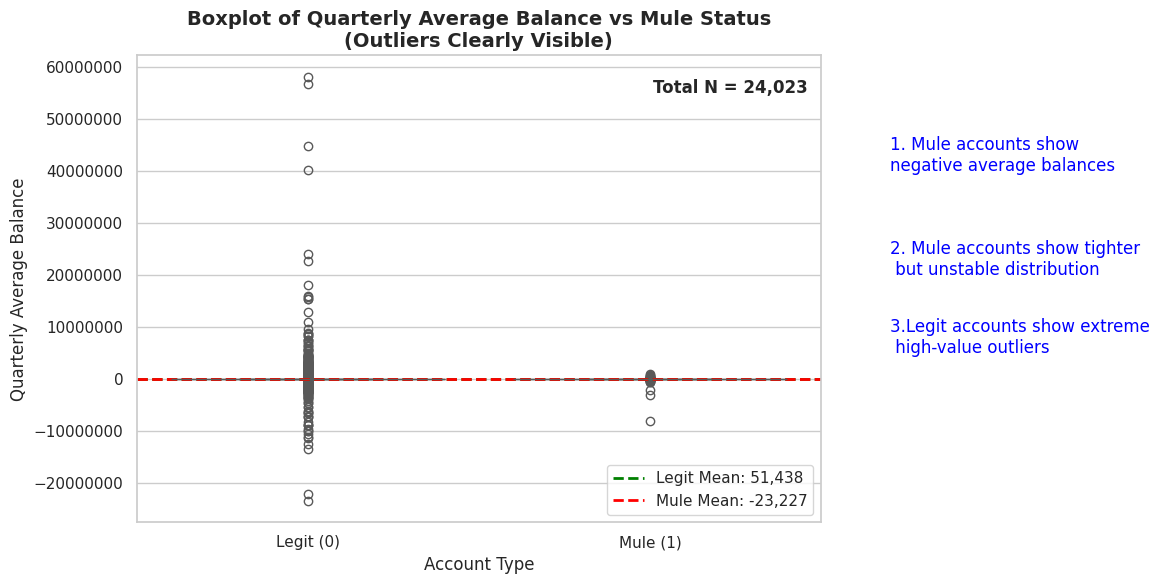

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

ax = sns.boxplot(
    data=train,
    x='is_mule',
    y='quarterly_avg_balance',
    palette='Set2',
    showfliers=True
)

# Calculate means
mean_legit = train[train['is_mule']==0]['quarterly_avg_balance'].mean()
mean_mule = train[train['is_mule']==1]['quarterly_avg_balance'].mean()

# Add mean lines
plt.axhline(mean_legit, color='green', linestyle='--', linewidth=2,
            label=f'Legit Mean: {mean_legit:,.0f}')

plt.axhline(mean_mule, color='red', linestyle='--', linewidth=2,
            label=f'Mule Mean: {mean_mule:,.0f}')

# Add total count
plt.text(
    0.98, 0.95,
    f'Total N = {len(train):,}',
    transform=plt.gca().transAxes,
    ha='right',
    va='top',
    fontsize=12,
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.6)
)

plt.title(
    "Boxplot of Quarterly Average Balance vs Mule Status\n(Outliers Clearly Visible)",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Account Type")
plt.ylabel("Quarterly Average Balance")

plt.xticks([0,1], ["Legit (0)", "Mule (1)"])


plt.text(x=1.7,y=40000000,s="1. Mule accounts show \nnegative average balances",color="blue")
plt.text(x=1.7,y=20000000,s="2. Mule accounts show tighter\n but unstable distribution",color="blue")
plt.text(x=1.7,y=5000000,s="3.Legit accounts show extreme\n high-value outliers",color="blue")

plt.ticklabel_format(style='plain', axis='y')

plt.legend()

plt.tight_layout()
plt.show()

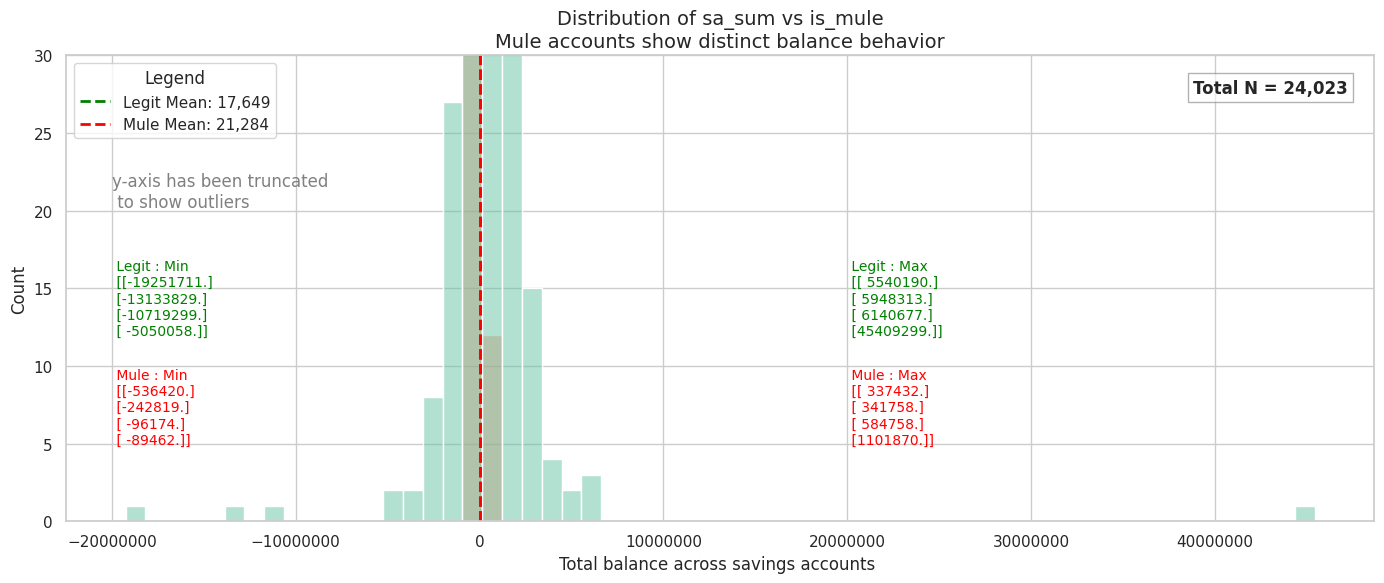

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# set avg bal to actaul nos. avoid scitific notation
plt.figure(figsize=(14,6))

np.set_printoptions(suppress=True)
# Plot histogram with  so mule is visible
ax = sns.histplot(
    data=train,
    x='sa_sum',
    hue='is_mule',
    bins=60,
    stat='count',
    common_norm=False,
    palette='Set2',
    alpha=0.5
)

plt.ylim(0,30)

# Calculate means
mean_legit = train[train['is_mule']==0]['sa_sum'].mean()
mean_mule = train[train['is_mule']==1]['sa_sum'].mean()

min_legit = sorted(train[train['is_mule']==0]['sa_sum'].round())[0:4]
min_legit = np.vstack(min_legit)

max_legit = sorted(train[train['is_mule']==0]['sa_sum'].round())[-4:]
max_legit = np.vstack(max_legit)

min_mule = sorted(train[train['is_mule']==1]['sa_sum'].round())[0:4]
min_mule = np.vstack(min_mule)

max_mule = sorted(train[train['is_mule']==1]['sa_sum'].round())[-4:]
max_mule = np.vstack(max_mule)

# Add mean lines
plt.axvline(mean_legit, color='green', linestyle='--', linewidth=2,
            label=f'Legit Mean: {mean_legit:,.0f}')

plt.axvline(mean_mule, color='red', linestyle='--', linewidth=2,
            label=f'Mule Mean: {mean_mule:,.0f}')

# Add total count
plt.text(
    0.98, 0.95,
    f'Total N = {len(train):,}',
    transform=plt.gca().transAxes,
    ha='right',
    va='top',
    fontsize=12,
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray')
)

plt.text(x =  -20_000_000, y = 12, s = f' Legit : Min\n {min_legit}', size = 10, color = 'green' )
plt.text(x =  20_000_000, y = 12, s = f' Legit : Max\n {max_legit}', size = 10, color = 'green' )
plt.text(x= -20_000_000, y=20, s="y-axis has been truncated \n to show outliers",ha="left",va="bottom", color = 'grey')
plt.text(x =  -20_000_000, y = 5, s = f' Mule : Min\n {min_mule}', size = 10, color = 'red' )
plt.text(x =  20_000_000, y = 5, s = f' Mule : Max\n {max_mule}', size = 10, color = 'red' )

# Labels and title
plt.title(
    "Distribution of sa_sum vs is_mule\nMule accounts show distinct balance behavior",
    fontsize=14
)

plt.xlabel("Total balance across savings accounts ")

plt.ylabel("Count")
plt.ticklabel_format(style='plain', axis='both')
plt.legend(title="Legend")

plt.tight_layout()

plt.show()

/tmp/ipython-input-250155470.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


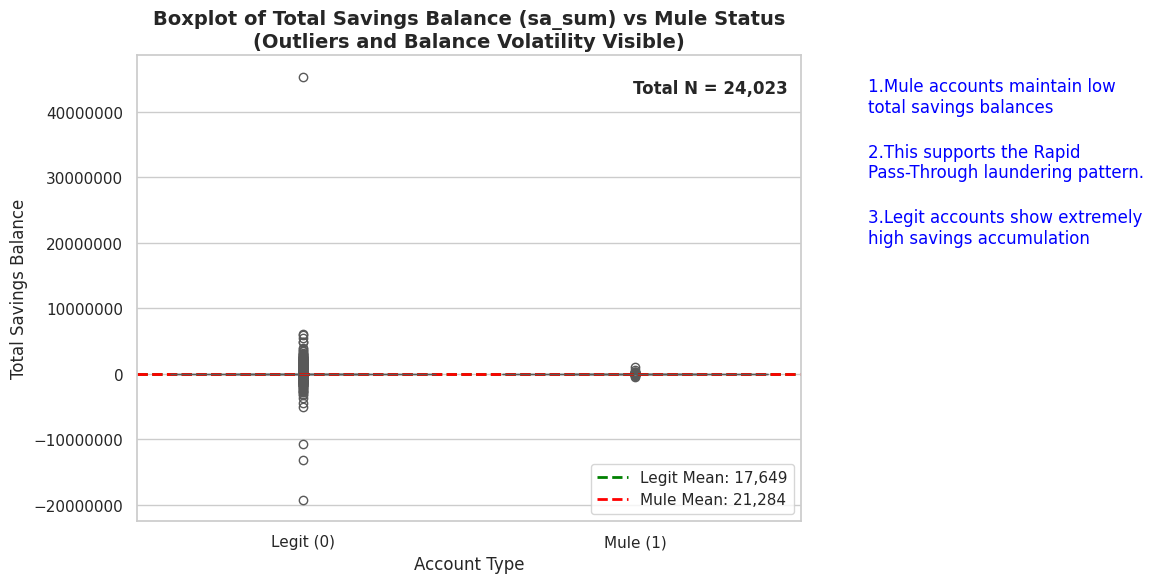

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

ax = sns.boxplot(
    data=train,
    x='is_mule',
    y='sa_sum',
    palette='Set2',
    showfliers=True
)

# Calculate means
mean_legit = train[train['is_mule']==0]['sa_sum'].mean()
mean_mule = train[train['is_mule']==1]['sa_sum'].mean()

# Add mean lines
plt.axhline(mean_legit, color='green', linestyle='--', linewidth=2,
            label=f'Legit Mean: {mean_legit:,.0f}')

plt.axhline(mean_mule, color='red', linestyle='--', linewidth=2,
            label=f'Mule Mean: {mean_mule:,.0f}')

# Add total count
plt.text(
    0.98, 0.95,
    f'Total N = {len(train):,}',
    transform=plt.gca().transAxes,
    ha='right',
    va='top',
    fontsize=12,
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.6)
)

plt.title(
    "Boxplot of Total Savings Balance (sa_sum) vs Mule Status\n(Outliers and Balance Volatility Visible)",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Account Type")
plt.ylabel("Total Savings Balance")

plt.xticks([0,1], ["Legit (0)", "Mule (1)"])

plt.text(x=1.7,y=40000000,s="1.Mule accounts maintain low \ntotal savings balances",color="blue")
plt.text(x=1.7,y=30000000,s="2.This supports the Rapid \nPass-Through laundering pattern.",color="blue")
plt.text(x=1.7,y=20000000,s="3.Legit accounts show extremely \nhigh savings accumulation",color="blue")

plt.ticklabel_format(style='plain', axis='y')

plt.legend()

plt.tight_layout()
plt.show()

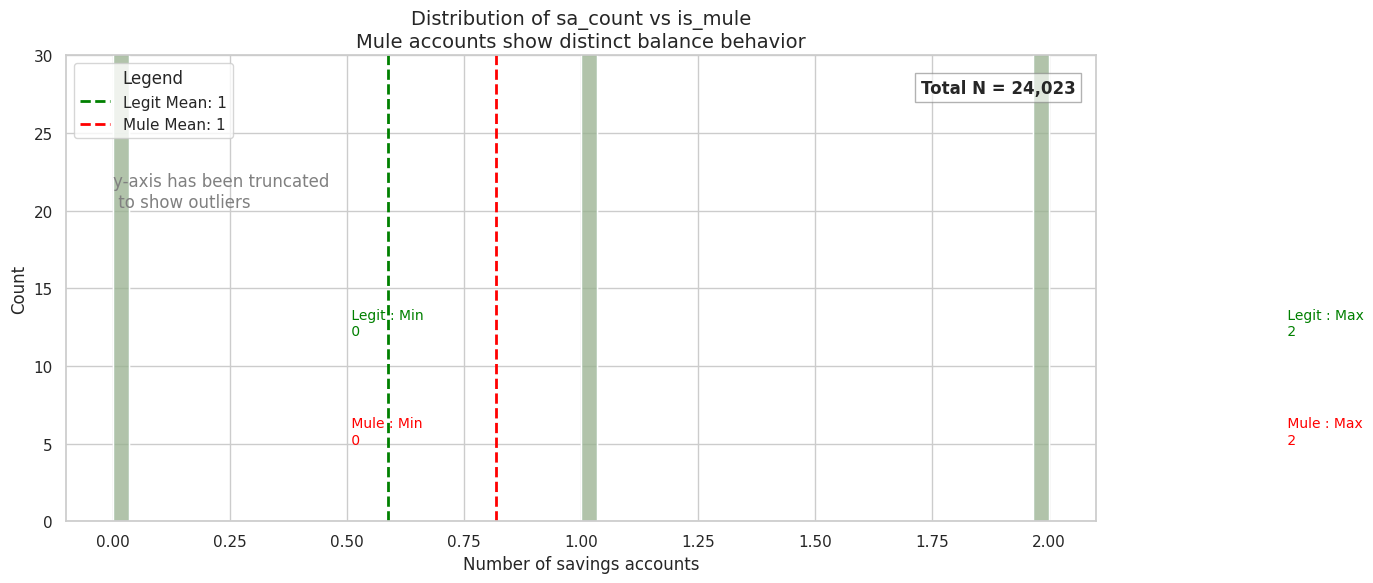

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# set avg bal to actaul nos. avoid scitific notation
plt.figure(figsize=(14,6))

np.set_printoptions(suppress=True)
# Plot histogram with  so mule is visible
ax = sns.histplot(
    data=train,
    x='sa_count',
    hue='is_mule',
    bins=60,
    stat='count',
    common_norm=False,
    palette='Set2',
    alpha=0.5
)

plt.ylim(0,30)

# Calculate means
mean_legit = train[train['is_mule']==0]['sa_count'].mean()
mean_mule = train[train['is_mule']==1]['sa_count'].mean()

# Get scalar min/max values
min_legit_val = train[train['is_mule']==0]['sa_count'].min()
max_legit_val = train[train['is_mule']==0]['sa_count'].max()

min_mule_val = train[train['is_mule']==1]['sa_count'].min()
max_mule_val = train[train['is_mule']==1]['sa_count'].max()

# Add mean lines
plt.axvline(mean_legit, color='green', linestyle='--', linewidth=2,
            label=f'Legit Mean: {mean_legit:,.0f}')

plt.axvline(mean_mule, color='red', linestyle='--', linewidth=2,
            label=f'Mule Mean: {mean_mule:,.0f}')

# Add total count
plt.text(
    0.98, 0.95,
    f'Total N = {len(train):,}',
    transform=plt.gca().transAxes,
    ha='right',
    va='top',
    fontsize=12,
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray')
)

# Adjusted text placement and content
plt.text(x =  0.5, y = 12, s = f' Legit : Min\n {min_legit_val}', size = 10, color = 'green' )
plt.text(x =  2.5, y = 12, s = f' Legit : Max\n {max_legit_val}', size = 10, color = 'green' )
plt.text(x= 0.0, y=20, s="y-axis has been truncated \n to show outliers",ha="left",va="bottom", color = 'grey')
plt.text(x =  0.5, y = 5, s = f' Mule : Min\n {min_mule_val}', size = 10, color = 'red' )
plt.text(x =  2.5, y = 5, s = f' Mule : Max\n {max_mule_val}', size = 10, color = 'red' )

# Labels and title
plt.title(
    "Distribution of sa_count vs is_mule\nMule accounts show distinct balance behavior",
    fontsize=14
)

plt.xlabel("Number of savings accounts")

plt.ylabel("Count")
plt.ticklabel_format(style='plain', axis='both')
plt.legend(title="Legend")

plt.tight_layout()

plt.show()

/tmp/ipython-input-2463844561.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


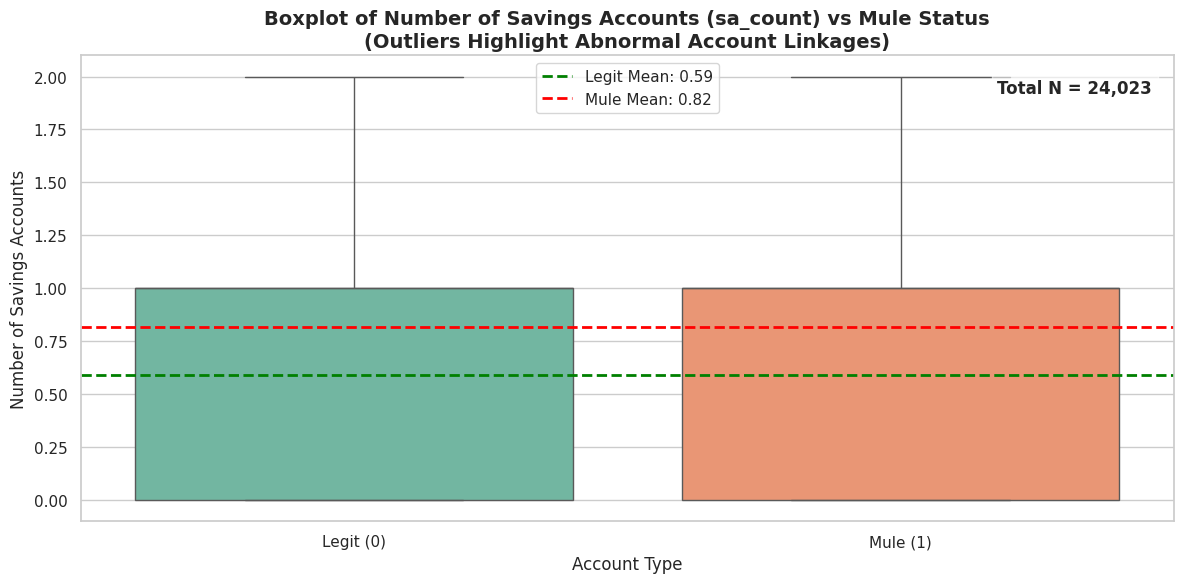

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

ax = sns.boxplot(
    data=train,
    x='is_mule',
    y='sa_count',
    palette='Set2',
    showfliers=True
)

# Calculate means
mean_legit = train[train['is_mule']==0]['sa_count'].mean()
mean_mule = train[train['is_mule']==1]['sa_count'].mean()

# Add mean lines
plt.axhline(mean_legit, color='green', linestyle='--', linewidth=2,
            label=f'Legit Mean: {mean_legit:.2f}')

plt.axhline(mean_mule, color='red', linestyle='--', linewidth=2,
            label=f'Mule Mean: {mean_mule:.2f}')

# Add total count
plt.text(
    0.98, 0.95,
    f'Total N = {len(train):,}',
    transform=plt.gca().transAxes,
    ha='right',
    va='top',
    fontsize=12,
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.6)
)

plt.title(
    "Boxplot of Number of Savings Accounts (sa_count) vs Mule Status\n(Outliers Highlight Abnormal Account Linkages)",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Account Type")
plt.ylabel("Number of Savings Accounts")

plt.xticks([0,1], ["Legit (0)", "Mule (1)"])

plt.legend()

plt.tight_layout()
plt.show()

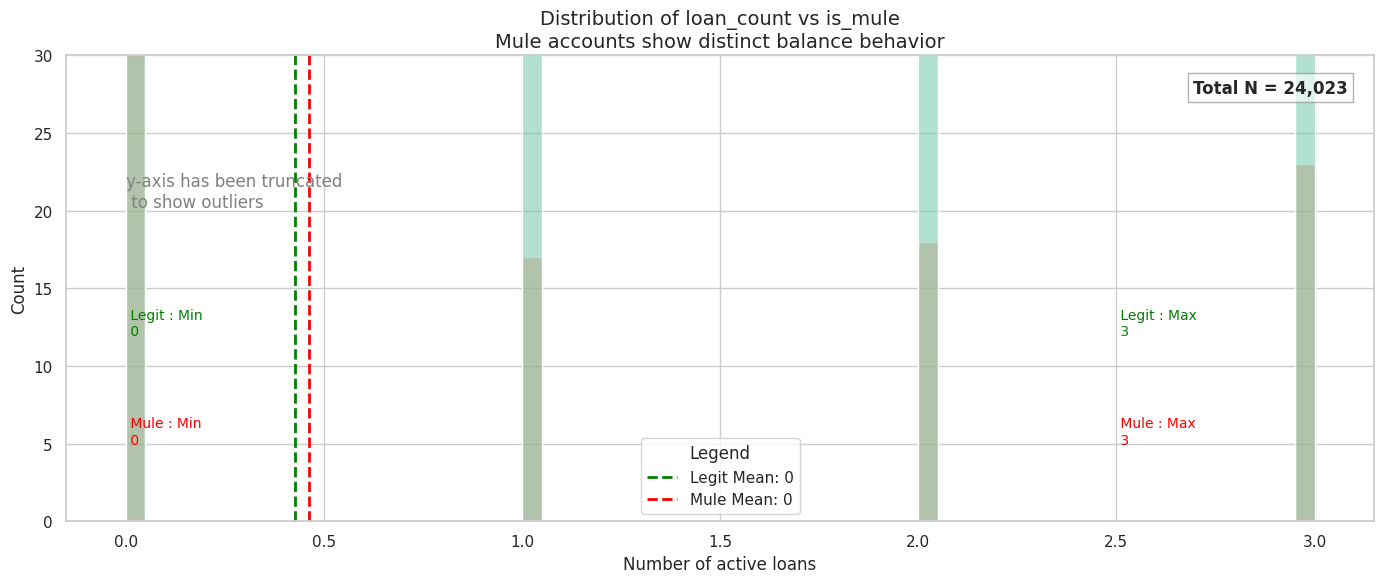

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# set avg bal to actaul nos. avoid scitific notation
plt.figure(figsize=(14,6))

np.set_printoptions(suppress=True)
# Plot histogram with  so mule is visible
ax = sns.histplot(
    data=train,
    x='loan_count',
    hue='is_mule',
    bins=60,
    stat='count',
    common_norm=False,
    palette='Set2',
    alpha=0.5
)

plt.ylim(0,30)

# Calculate means
mean_legit = train[train['is_mule']==0]['loan_count'].mean()
mean_mule = train[train['is_mule']==1]['loan_count'].mean()

# Get scalar min/max values
min_legit_val = train[train['is_mule']==0]['loan_count'].min()
max_legit_val = train[train['is_mule']==0]['loan_count'].max()

min_mule_val = train[train['is_mule']==1]['loan_count'].min()
max_mule_val = train[train['is_mule']==1]['loan_count'].max()

# Add mean lines
plt.axvline(mean_legit, color='green', linestyle='--', linewidth=2,
            label=f'Legit Mean: {mean_legit:,.0f}')

plt.axvline(mean_mule, color='red', linestyle='--', linewidth=2,
            label=f'Mule Mean: {mean_mule:,.0f}')

# Add total count
plt.text(
    0.98, 0.95,
    f'Total N = {len(train):,}',
    transform=plt.gca().transAxes,
    ha='right',
    va='top',
    fontsize=12,
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray')
)

# Adjusted text placement and content
plt.text(x =  0, y = 12, s = f' Legit : Min\n {min_legit_val}', size = 10, color = 'green' )
plt.text(x =  2.5, y = 12, s = f' Legit : Max\n {max_legit_val}', size = 10, color = 'green' )
plt.text(x= 0.0, y=20, s="y-axis has been truncated \n to show outliers",ha="left",va="bottom", color = 'grey')
plt.text(x =  0, y = 5, s = f' Mule : Min\n {min_mule_val}', size = 10, color = 'red' )
plt.text(x =  2.5, y = 5, s = f' Mule : Max\n {max_mule_val}', size = 10, color = 'red' )

# Labels and title
plt.title(
    "Distribution of loan_count vs is_mule\nMule accounts show distinct balance behavior",
    fontsize=14
)

plt.xlabel("Number of active loans")

plt.ylabel("Count")
plt.ticklabel_format(style='plain', axis='both')
plt.legend(title="Legend")

plt.tight_layout()

plt.show()

## A.2 Remaining Histograms for Numerical variables


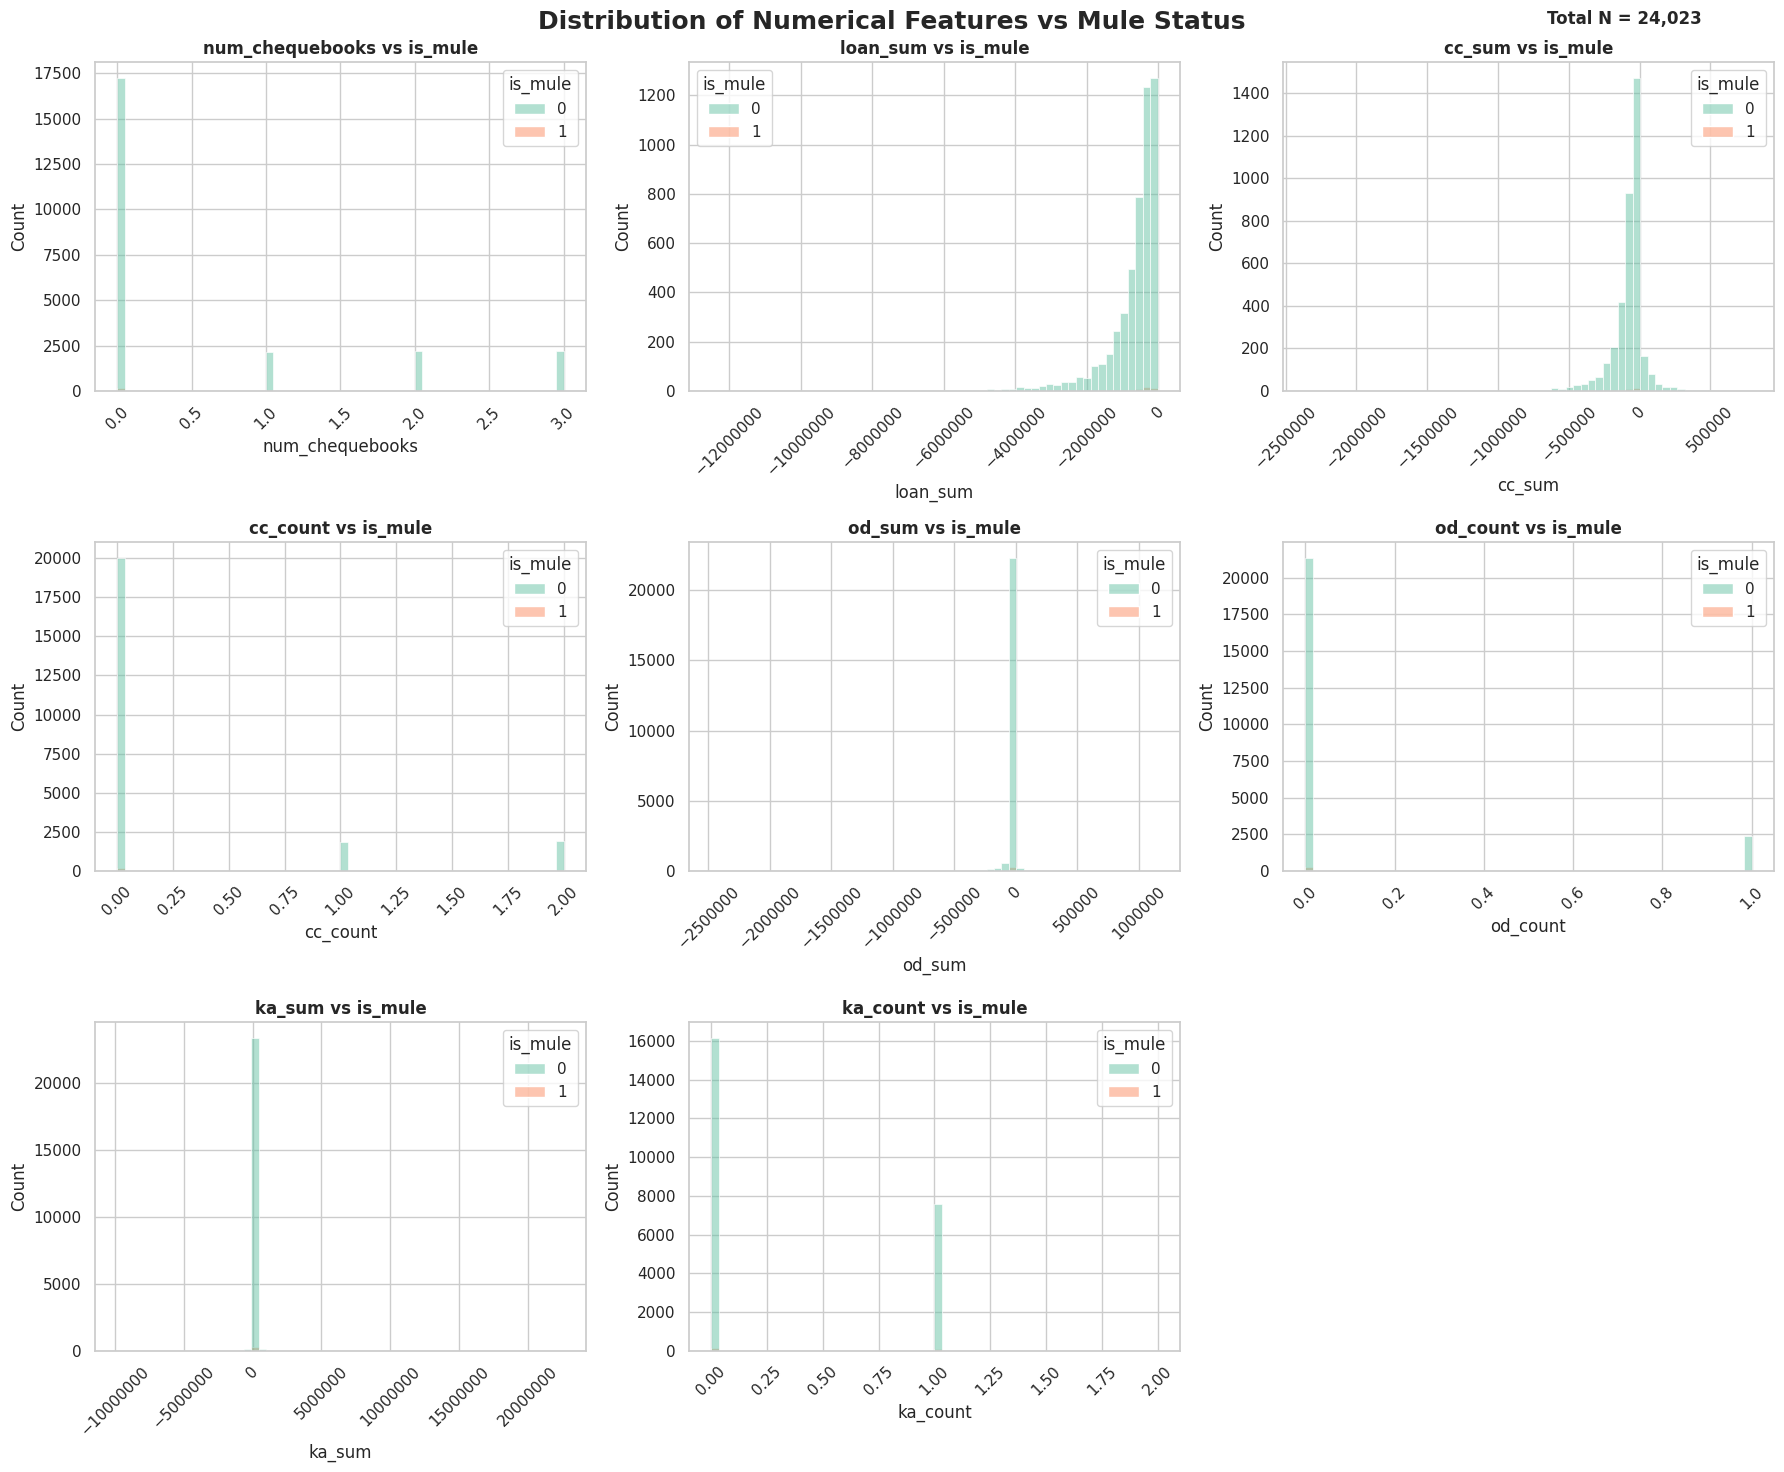

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols_filtered = [
    'num_chequebooks',
    'loan_sum',
    'cc_sum',
    'cc_count',
    'od_sum',
    'od_count',
    'ka_sum',
    'ka_count'
]

n_cols = 3
n_rows = (len(num_cols_filtered) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5*n_rows)
)

axes = axes.flatten()

for i, col in enumerate(num_cols_filtered):

    ax = axes[i]

    sns.histplot(
        data=train,
        x=col,
        hue='is_mule',
        bins=60,
        stat='count',
        common_norm=False,
        palette='Set2',
        alpha=0.5,
        ax=ax
    )

    ax.set_title(f"{col} vs is_mule", fontsize=12, fontweight='bold')

    ax.ticklabel_format(style='plain', axis='x')
    ax.tick_params(axis='x', rotation=45)

# Remove empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Add Total N
fig.text(
    0.95, 0.98,
    f'Total N = {len(train):,}',
    ha='right',
    va='top',
    fontsize=12,
    fontweight='bold'
)

fig.suptitle(
    "Distribution of Numerical Features vs Mule Status",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

#4 Heatmaps and Correlation matrix

In [ ]:
# Check if is_mule is numeric
print(train['is_mule'].dtype)

# If not numeric, convert it
train['is_mule'] = train['is_mule'].astype(int)

int64


In [ ]:
num_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Make sure is_mule is included
if 'is_mule' not in num_cols:
    num_cols.append('is_mule')

numeric_df = train[num_cols]

In [ ]:
corr_matrix = numeric_df.corr()

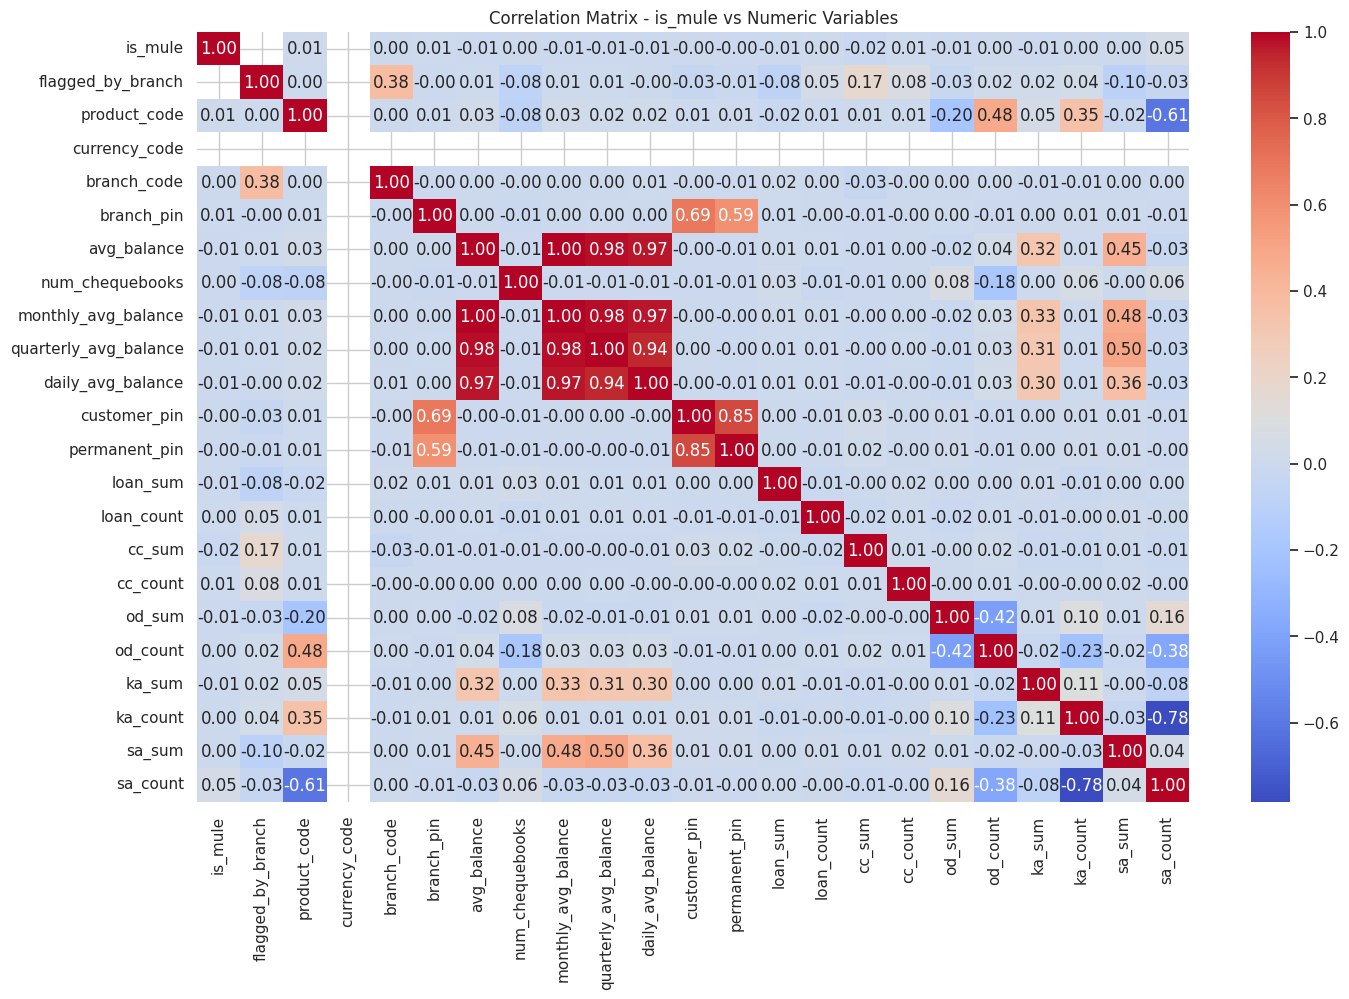

In [ ]:
plt.figure(figsize=(16,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix - is_mule vs Numeric Variables")
plt.show()

In [ ]:
is_mule_corr = corr_matrix.loc['is_mule']

In [ ]:
is_mule_corr_df = is_mule_corr.reset_index()
is_mule_corr_df.columns = ['Feature', 'Correlation']

In [ ]:
sorted_corr = is_mule_corr_df.sort_values(by='Correlation', ascending=False)

print(sorted_corr)

                  Feature  Correlation
0                 is_mule     1.000000
22               sa_count     0.047197
2            product_code     0.011123
5              branch_pin     0.008816
16               cc_count     0.006491
14             loan_count     0.004065
20               ka_count     0.003847
7         num_chequebooks     0.003704
4             branch_code     0.001656
21                 sa_sum     0.000993
18               od_count     0.000468
11           customer_pin    -0.002673
12          permanent_pin    -0.004678
17                 od_sum    -0.006279
13               loan_sum    -0.006619
10      daily_avg_balance    -0.007788
9   quarterly_avg_balance    -0.008874
8     monthly_avg_balance    -0.008918
19                 ka_sum    -0.009517
6             avg_balance    -0.009673
15                 cc_sum    -0.019692
1       flagged_by_branch          NaN
3           currency_code          NaN


In [ ]:
revised_numeric_features = sorted_corr['Feature'].tolist()

print("Revised Numeric Feature Set:")
print(revised_numeric_features)

Revised Numeric Feature Set:
['is_mule', 'sa_count', 'product_code', 'branch_pin', 'cc_count', 'loan_count', 'ka_count', 'num_chequebooks', 'branch_code', 'sa_sum', 'od_count', 'customer_pin', 'permanent_pin', 'od_sum', 'loan_sum', 'daily_avg_balance', 'quarterly_avg_balance', 'monthly_avg_balance', 'ka_sum', 'avg_balance', 'cc_sum', 'flagged_by_branch', 'currency_code']


In [ ]:
sorted_abs_corr = is_mule_corr_df.reindex(
    is_mule_corr_df['Correlation'].abs().sort_values(ascending=False).index
)

print(sorted_abs_corr)

                  Feature  Correlation
0                 is_mule     1.000000
22               sa_count     0.047197
15                 cc_sum    -0.019692
2            product_code     0.011123
6             avg_balance    -0.009673
19                 ka_sum    -0.009517
8     monthly_avg_balance    -0.008918
9   quarterly_avg_balance    -0.008874
5              branch_pin     0.008816
10      daily_avg_balance    -0.007788
13               loan_sum    -0.006619
16               cc_count     0.006491
17                 od_sum    -0.006279
12          permanent_pin    -0.004678
14             loan_count     0.004065
20               ka_count     0.003847
7         num_chequebooks     0.003704
11           customer_pin    -0.002673
4             branch_code     0.001656
21                 sa_sum     0.000993
18               od_count     0.000468
1       flagged_by_branch          NaN
3           currency_code          NaN


In [ ]:
cat_cols = train.select_dtypes(include=['object']).columns.tolist()

le = LabelEncoder()

for col in cat_cols:
    train[col] = le.fit_transform(train[col].astype(str))

In [ ]:
cat_df = train[ ['is_mule'] + cat_cols ]

cat_corr_matrix = cat_df.corr()

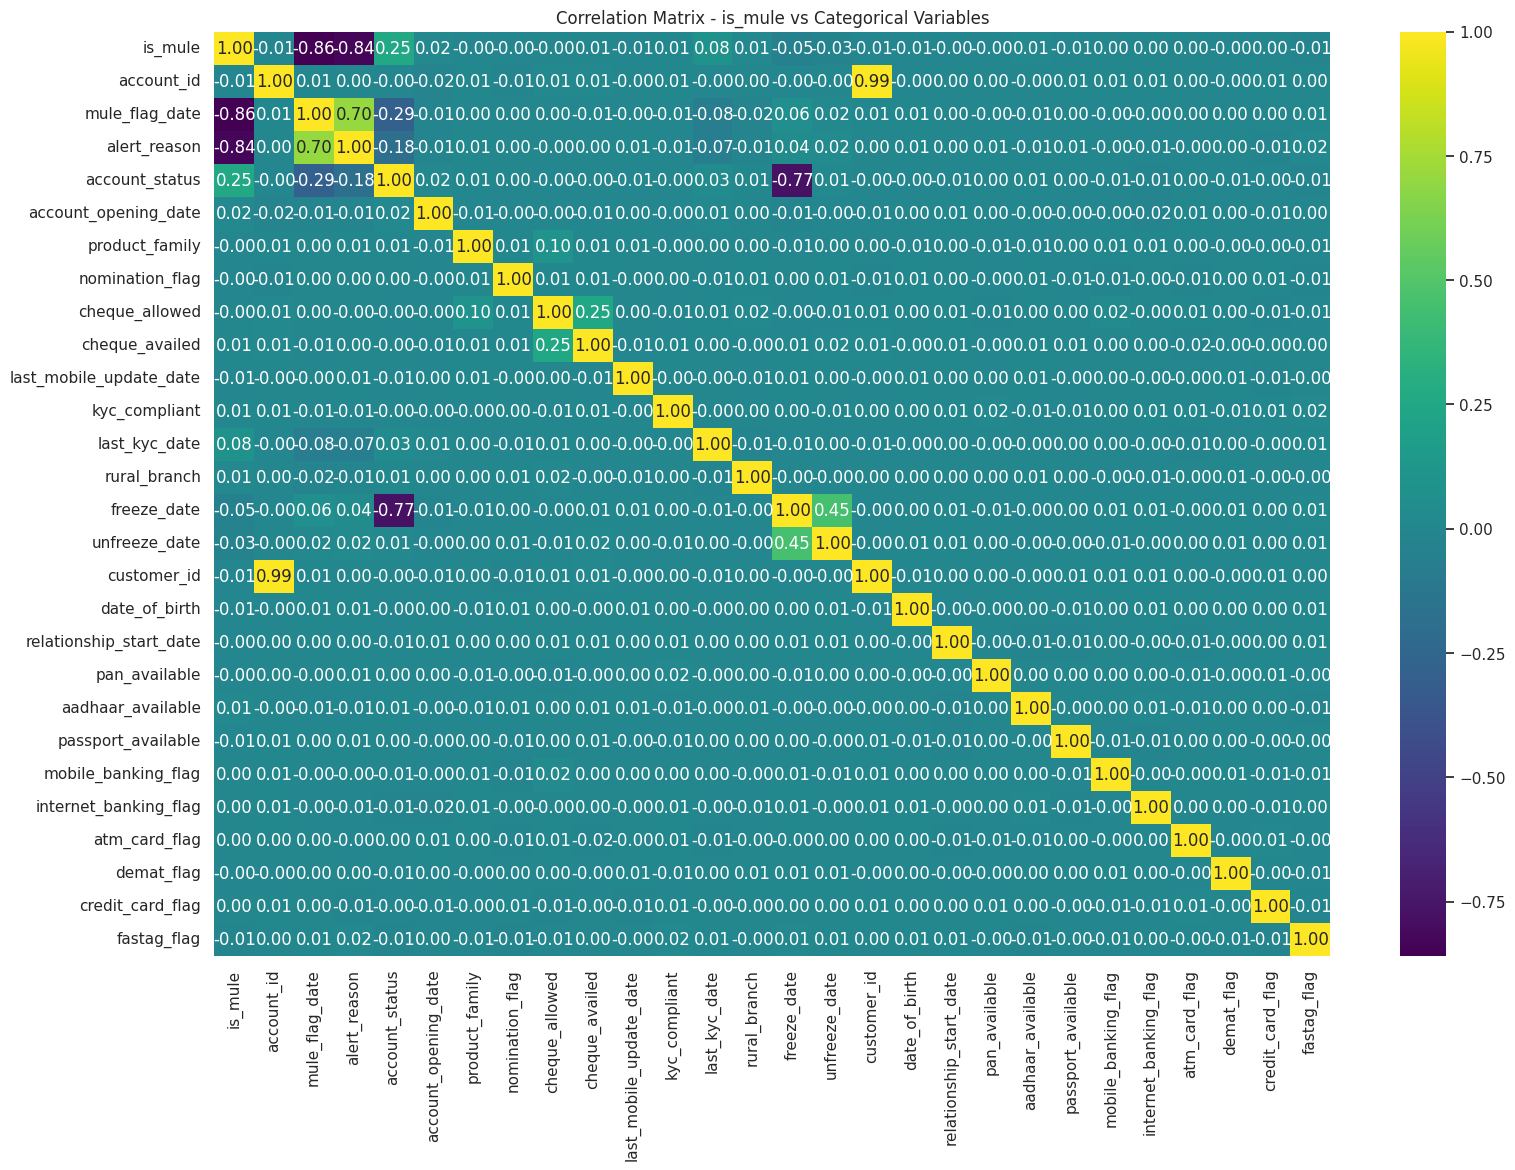

In [ ]:
plt.figure(figsize=(18,12))
sns.heatmap(cat_corr_matrix, annot=True, cmap='viridis', fmt=".2f")
plt.title("Correlation Matrix - is_mule vs Categorical Variables")
plt.show()

In [ ]:
is_mule_cat_corr = cat_corr_matrix.loc['is_mule']

is_mule_cat_corr_df = is_mule_cat_corr.reset_index()
is_mule_cat_corr_df.columns = ['Feature', 'Correlation']

sorted_cat_corr = is_mule_cat_corr_df.sort_values(by='Correlation', ascending=False)

print(sorted_cat_corr)

                    Feature  Correlation
0                   is_mule     1.000000
4            account_status     0.254684
12            last_kyc_date     0.084879
5      account_opening_date     0.017386
13             rural_branch     0.013971
20        aadhaar_available     0.012947
9            cheque_availed     0.008035
11            kyc_compliant     0.005662
22      mobile_banking_flag     0.004192
26         credit_card_flag     0.003849
23    internet_banking_flag     0.001782
24            atm_card_flag     0.001456
8            cheque_allowed    -0.000835
18  relationship_start_date    -0.002664
25               demat_flag    -0.002998
19            pan_available    -0.003014
7           nomination_flag    -0.003170
6            product_family    -0.003282
10  last_mobile_update_date    -0.005109
16              customer_id    -0.006422
1                account_id    -0.007105
21       passport_available    -0.007147
17            date_of_birth    -0.008174
27              

In [ ]:
revised_categorical_features = sorted_cat_corr['Feature'].tolist()

print("Revised Categorical Feature Set:")
print(revised_categorical_features)

Revised Categorical Feature Set:
['is_mule', 'account_status', 'last_kyc_date', 'account_opening_date', 'rural_branch', 'aadhaar_available', 'cheque_availed', 'kyc_compliant', 'mobile_banking_flag', 'credit_card_flag', 'internet_banking_flag', 'atm_card_flag', 'cheque_allowed', 'relationship_start_date', 'demat_flag', 'pan_available', 'nomination_flag', 'product_family', 'last_mobile_update_date', 'customer_id', 'account_id', 'passport_available', 'date_of_birth', 'fastag_flag', 'unfreeze_date', 'freeze_date', 'alert_reason', 'mule_flag_date']
